# Feature Visualization

This notebook loads:
1. Trained probe weights and configurations from WandB
2. Activations from HuggingFace  
3. Questions, labels, and model outputs from the dataset files

In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import torch
import tqdm

import probe_gen.probes as probes
from probe_gen.config import ConfigDict, data
from probe_gen.standard_experiments.hyperparameter_search import get_best_hyperparams_for_train_setup

# Configuration for feature visualization
probe_type = "mean"  # Options: "mean", "attention_torch", "mean_torch"
behaviour = "science"
datasource = "ultrachat"
activations_model = "llama_3b"
generation_method = "on_policy"
response_model = "llama_3b"
mode = "train"

## 1. Train a probe


In [2]:
from probe_gen.standard_experiments.token_heatmaps import train_probe_on

probe = train_probe_on(probe_type, behaviour, datasource, activations_model, generation_method, response_model, mode, verbose=True)

Loaded hyperparameters:
  Layer: 12
  Use bias: True
  Normalize: True
  C (inverse ofregularization): 0.01
loaded activations with shape torch.Size([5000, 257, 3072])
calculated attention mask with shape torch.Size([5000, 257])
loaded labels

Loaded data:
  Activations shape: torch.Size([5000, 257, 3072])
  Attention mask shape: torch.Size([5000, 257])
  Labels shape: torch.Size([5000])
  Positive samples: 2500
  Negative samples: 2500
Aggregated activations shape: torch.Size([5000, 3072])
Train: 3500 samples, 1750.0 positives
Val:   500 samples, 250.0 positives
Test:  0 samples, 0.0 positives

Training probe...

✓ Validation ROC-AUC: 0.9447
  Accuracy: 0.8560


## 2. Load Activations and Labelled Responses from HuggingFace

Load the pre-computed activations at the specified layer


In [3]:
from probe_gen.standard_experiments.token_heatmaps import load_labelled_responses_and_activations
responses_df, activations_tensor, attention_mask, labels_tensor = load_labelled_responses_and_activations(
    probe_type, behaviour, datasource, activations_model, generation_method, response_model, mode, verbose=False
)

ultrachat/llama_3b_on_policy_train.jsonl:   0%|          | 0.00/11.2M [00:00<?, ?B/s]

## 5. Extract Probe Weights

Extract the learned weights from the trained probe for visualization


In [5]:
from probe_gen.standard_experiments.token_heatmaps import extract_probe_weights
probe_weights, probe_bias = extract_probe_weights(probe)

## 7. Visualize Probe Scores for Question + Answer Pairs

This cell shows how to compute and visualize probe scores for both the question and answer together


In [ ]:
from probe_gen.gen_data.utils import format_prompts_from_pairs, _prepare_batch_inputs, get_pad_token

# IMPROVED: Show probe scores for both question AND answer
from transformers import AutoTokenizer

model_name = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "left"
tokenizer.pad_token = get_pad_token(model_name, tokenizer)

print(responses_df.columns)



example_idx = 0
if 'input' in responses_df.columns and 'model_outputs' in responses_df.columns:

    inputs = json.loads(responses_df.iloc[example_idx]["inputs"])
    human = inputs[0]["content"]
    assistant = inputs[1]["content"]
    formatted_pairs = format_prompts_from_pairs(tokenizer, [human], [assistant])
    print(formatted_pairs)

    inputs = _prepare_batch_inputs(tokenizer, formatted_pairs, max_length=None)
    print(inputs.shape)


    question = responses_df.iloc[example_idx]['input']
    print(question)
    answer = responses_df.iloc[example_idx]['model_outputs']
    
    # Combine question and answer
    full_text = question + " " + answer
    
    print(f"Question: {question[:50]}...")
    print(f"Answer: {answer[:50]}...\n")
    
    # Tokenize the full question + answer
    tokens = tokenizer.tokenize(full_text)
    question_tokens = tokenizer.tokenize(question)
    num_question_tokens = len(question_tokens)
    num_real_tokens = min(len(tokens), int(attention_mask[example_idx].sum().item()))
    
    print(f"{'='*90}")
    print(f"PROBE SCORES FOR QUESTION + ANSWER ({num_real_tokens} tokens)")
    print(f"{'='*90}\n")
    
    print(activations_tensor[example_idx].shape)

    # For each token, get the probe score:
    for i, (token, activation) in enumerate(zip(tokens[:num_real_tokens], activations_tensor[example_idx][:num_real_tokens])):
        probe_score = np.dot(activation.numpy(), probe_weights) + probe_bias
        
        # Mark whether this is in the question or answer
        section = "QUESTION" if i < num_question_tokens else "ANSWER  "
        print(f"[{section}] Token {i:3d}: {token:25s} -> Probe score: {probe_score:7.3f}")


NameError: name 'get_pad_token' is not defined

## 8. Probe Score Interpretation with Probabilities

This cell provides better interpretation of probe scores by:
1. Converting logits to probabilities using sigmoid
2. Showing statistics about score distribution
3. Highlighting the top tokens most/least associated with the behavior


In [16]:
# print 100 example questions and answers with index
for i, (q, a) in enumerate(zip(dataset_df['input'], dataset_df['model_outputs'])):
    print(f"Question: {q}...")
    print(f"Answer: {a}...\n")
    print(f"{'='*90}")


Question: Three points are chosen randomly and independently on a circle. What is the probability that all three pairwise distances between the points are less than the radius of the circle?

A. \frac{1}{20}
B. \frac{1}{32}
C. \frac{1}{12}
D. \frac{1}{16}...
Answer: To solve this problem, we first note that if $d(x, y)$ denotes the distance between points $x$ and $y$, then the points $x$, $y$, and $z$ are on the circle if $$d(x, y) = d(x, z) = d(y, z) \le 2r,$$where $r$...

Question: A 10 kg box slides horizontally without friction at a speed of 1 m/s. At one point, a constant force is applied to the box in the direction of its motion. The box travels 5 m with the constant force applied. The force is then removed, leaving the box with a speed of 2 m/s. Which of the following gives the magnitude of the applied force?

A. 1 N
B. 2 N
C. 3 N
D. 4 N...
Answer: To solve this problem, we'll use the concept of impulse and momentum. Since the box is moving with a constant velocity initially, it

## 9. Compare Probe Scores: Label=1 vs Label=0

Analyze 10 examples from each class to see how probe scores differ


In [17]:
# Analyze 10 examples with label=1 and 10 with label=0
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")

def sigmoid(x):
    """Convert logit to probability"""
    return 1 / (1 + np.exp(-x))

def analyze_example(idx):
    """Analyze a single example and return statistics"""
    question = dataset_df.iloc[idx]['input']
    answer = dataset_df.iloc[idx]['model_outputs']
    label = labels_tensor[idx].item()
    
    # Tokenize
    full_text = question + " " + answer
    tokens = tokenizer.tokenize(full_text)
    question_tokens = tokenizer.tokenize(question)
    num_question_tokens = len(question_tokens)
    num_real_tokens = min(len(tokens), int(attention_mask[idx].sum().item()))
    
    # Compute scores
    scores = []
    for i in range(num_real_tokens):
        activation = activations_tensor[idx][i]
        score = np.dot(activation.numpy(), probe_weights) + probe_bias
        scores.append(score)
    
    mean_score = np.mean(scores)
    max_score = np.max(scores)
    min_score = np.min(scores)
    
    return {
        'idx': idx,
        'label': label,
        'question': question,
        'answer': answer,
        'mean_score': mean_score,
        'max_score': max_score,
        'min_score': min_score,
        'mean_prob': sigmoid(mean_score),
        'num_tokens': len(scores)
    }

# Find indices for label=1 and label=0
label_1_indices = [i for i, label in enumerate(labels_tensor) if label.item() == 1]
label_0_indices = [i for i, label in enumerate(labels_tensor) if label.item() == 0]

print(f"Found {len(label_1_indices)} examples with label=1")
print(f"Found {len(label_0_indices)} examples with label=0\n")

# Analyze 10 examples from each class
n_examples = 10
results_label_1 = [analyze_example(idx) for idx in label_1_indices[:n_examples]]
results_label_0 = [analyze_example(idx) for idx in label_0_indices[:n_examples]]

# Display results for LABEL=1
print("="*120)
print(f"EXAMPLES WITH LABEL = 1 (Positive for '{behaviour}' behavior)")
print("="*120)
for i, result in enumerate(results_label_1, 1):
    print(f"\nExample {i} (Index {result['idx']}):")
    print(f"  Question: {result['question']}...")
    print(f"  Answer: {result['answer']}...")
    print(f"  Mean score: {result['mean_score']:6.3f} (Probability: {result['mean_prob']:.3f})")
    print(f"  Score range: [{result['min_score']:6.3f}, {result['max_score']:6.3f}]")

# Calculate aggregate statistics for label=1
mean_scores_1 = [r['mean_score'] for r in results_label_1]
print(f"\n{'='*120}")
print(f"AGGREGATE STATISTICS FOR LABEL=1 ({n_examples} examples):")
print(f"  Average mean score: {np.mean(mean_scores_1):.3f} ± {np.std(mean_scores_1):.3f}")
print(f"  Average probability: {np.mean([r['mean_prob'] for r in results_label_1]):.3f}")

# Display results for LABEL=0
print(f"\n\n{'='*120}")
print(f"EXAMPLES WITH LABEL = 0 (Negative for '{behaviour}' behavior)")
print("="*120)
for i, result in enumerate(results_label_0, 1):
    print(f"\nExample {i} (Index {result['idx']}):")
    print(f"  Question: {result['question']}")
    print(f"  Answer: {result['answer']}")
    print(f"  Mean score: {result['mean_score']:6.3f} (Probability: {result['mean_prob']:.3f})")
    print(f"  Score range: [{result['min_score']:6.3f}, {result['max_score']:6.3f}]")

# Calculate aggregate statistics for label=0
mean_scores_0 = [r['mean_score'] for r in results_label_0]
print(f"\n{'='*120}")
print(f"AGGREGATE STATISTICS FOR LABEL=0 ({n_examples} examples):")
print(f"  Average mean score: {np.mean(mean_scores_0):.3f} ± {np.std(mean_scores_0):.3f}")
print(f"  Average probability: {np.mean([r['mean_prob'] for r in results_label_0]):.3f}")

# Compare the two groups
print(f"\n\n{'='*120}")
print(f"COMPARISON: LABEL=1 vs LABEL=0")
print("="*120)
print(f"  Label=1 mean score: {np.mean(mean_scores_1):6.3f} ± {np.std(mean_scores_1):.3f}")
print(f"  Label=0 mean score: {np.mean(mean_scores_0):6.3f} ± {np.std(mean_scores_0):.3f}")
print(f"  Difference: {np.mean(mean_scores_1) - np.mean(mean_scores_0):6.3f}")
print(f"\nThe probe {'correctly' if np.mean(mean_scores_1) > np.mean(mean_scores_0) else 'incorrectly'} assigns higher scores to label=1 examples on average")


Found 2500 examples with label=1
Found 2500 examples with label=0

EXAMPLES WITH LABEL = 1 (Positive for 'science' behavior)

Example 1 (Index 2):
  Question: The trigger to initiate the contractile process in skeletal muscle is:

A. potassium binding to myosin.
B. calcium binding to tropomyosin.
C. ATP binding to the myosin cross bridges.
D. calcium binding to troponin....
  Answer: The correct answer is D. calcium binding to troponin.

The trigger to initiate the contractile process in skeletal muscle is the binding of calcium ions (Ca2+) to troponin, a complex of three proteins embedded in the thin filaments (actin filaments) within the muscle cell. When Ca2+ ions bind to troponin, it causes a...
  Mean score:  0.480 (Probability: 0.618)
  Score range: [-14.074,  2.186]

Example 2 (Index 9):
  Question: Howard's idea of the garden city consisted of:

A. six small towns surrounded by green belts and linked to a larger central city
B. planning cities to have plenty of trees, flowers a

## 10. Detailed Token-Level Analysis for Selected Examples

Show full token-by-token probe scores for a few examples from each class


In [18]:
# Show detailed token-level scores for 2 examples from each class
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")

def show_detailed_tokens(idx, max_tokens=100):
    """Show token-by-token probe scores for an example"""
    question = dataset_df.iloc[idx]['input']
    answer = dataset_df.iloc[idx]['model_outputs']
    label = labels_tensor[idx].item()
    
    full_text = question + " " + answer
    tokens = tokenizer.tokenize(full_text)
    question_tokens = tokenizer.tokenize(question)
    num_question_tokens = len(question_tokens)
    num_real_tokens = min(len(tokens), int(attention_mask[idx].sum().item()), max_tokens)
    
    print(f"\n{'='*110}")
    print(f"EXAMPLE INDEX {idx} - TRUE LABEL: {label}")
    print(f"{'='*110}")
    print(f"Question: {question}")
    print(f"Answer: {answer}")
    print(f"\n{'-'*110}")
    print(f"TOKEN-BY-TOKEN PROBE SCORES (showing {num_real_tokens} tokens):")
    print(f"{'-'*110}\n")
    
    scores = []
    for i in range(num_real_tokens):
        activation = activations_tensor[idx][i]
        score = np.dot(activation.numpy(), probe_weights) + probe_bias
        prob = sigmoid(score)
        
        if abs(score) < 10:  # Only show non-outliers
            section = "QUESTION" if i < num_question_tokens else "ANSWER  "
            scores.append(score)
            print(f"[{section}] Token {i:3d}: {tokens[i]:25s} -> Score: {score:7.3f}  Prob: {prob:.3f}")
    
    mean_score = np.mean(scores)
    print(f"\n{'-'*110}")
    print(f"Mean score: {mean_score:.3f} (Probability: {sigmoid(mean_score):.3f})")
    print(f"Label: {label}  |  Probe prediction: {'Positive (1)' if mean_score > 0 else 'Negative (0)'}")
    print(f"{'='*110}\n")

# Show 2 examples from each class
print("="*110)
print("DETAILED TOKEN ANALYSIS: LABEL = 1 EXAMPLES")
print("="*110)

for i in range(2):
    show_detailed_tokens(label_1_indices[i], max_tokens=80)

print("\n\n" + "="*110)
print("DETAILED TOKEN ANALYSIS: LABEL = 0 EXAMPLES")
print("="*110)

for i in range(2):
    show_detailed_tokens(label_0_indices[i], max_tokens=80)


DETAILED TOKEN ANALYSIS: LABEL = 1 EXAMPLES

EXAMPLE INDEX 2 - TRUE LABEL: 1.0
Question: The trigger to initiate the contractile process in skeletal muscle is:

A. potassium binding to myosin.
B. calcium binding to tropomyosin.
C. ATP binding to the myosin cross bridges.
D. calcium binding to troponin.
Answer: The correct answer is D. calcium binding to troponin.

The trigger to initiate the contractile process in skeletal muscle is the binding of calcium ions (Ca2+) to troponin, a complex of three proteins embedded in the thin filaments (actin filaments) within the muscle cell. When Ca2+ ions bind to troponin, it causes a

--------------------------------------------------------------------------------------------------------------
TOKEN-BY-TOKEN PROBE SCORES (showing 80 tokens):
--------------------------------------------------------------------------------------------------------------

[QUESTION] Token   2: Ġto                       -> Score:   0.496  Prob: 0.621
[QUESTION] Token 

## 11. Understanding Token-Level Scores vs Sequence-Level Predictions

**Important distinction:**
- **Token-level scores**: Individual scores for each token (what we've been visualizing)
- **Sequence-level prediction**: The probe's actual prediction for the entire example

Since you use **mean aggregation**, the probe's prediction is based on the **mean of all token activations**, not individual tokens.

Token-level scores are for **interpretability/visualization only** - they show which parts of the input the probe associates with the behavior.


In [19]:
# Demonstrate the difference between token-level scores and sequence-level predictions
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("="*100)
print("TOKEN-LEVEL SCORES vs SEQUENCE-LEVEL PREDICTIONS")
print("="*100)

# Let's look at a few examples
example_indices = label_1_indices[:3] + label_0_indices[:3]

print("\nDETAILED BREAKDOWN FOR 6 EXAMPLES:\n")

for idx in example_indices:
    label = labels_tensor[idx].item()
    question = dataset_df.iloc[idx]['input']
    
    # Get all token activations (before aggregation)
    num_real_tokens = int(attention_mask[idx].sum().item())
    token_activations = activations_tensor[idx][:num_real_tokens]
    
    # Compute token-level scores (for visualization)
    token_scores = []
    for i in range(num_real_tokens):
        score = np.dot(token_activations[i].numpy(), probe_weights) + probe_bias
        token_scores.append(score)
    
    # Get the ACTUAL probe prediction (using mean-aggregated activation)
    # This is what the probe actually predicts on
    mean_activation = activations_aggregated[idx].numpy()
    sequence_score = np.dot(mean_activation, probe_weights) + probe_bias
    sequence_prob = sigmoid(sequence_score)
    
    print(f"Example {idx} (Label={label}):")
    print(f"  Question: {question}")
    print(f"  Token-level scores: min={np.min(token_scores):.3f}, mean={np.mean(token_scores):.3f}, max={np.max(token_scores):.3f}")
    print(f"  → SEQUENCE-LEVEL PREDICTION: score={sequence_score:.3f}, probability={sequence_prob:.3f}")
    print(f"  → True label: {label}")
    print()

print("="*100)
print("KEY INSIGHT:")
print("="*100)
print("The probe's ACTUAL prediction uses the mean-aggregated activation.")
print("Token-level scores help us understand WHICH TOKENS contribute to this mean,")
print("but the final prediction is a single score per sequence.\n")

print("="*100)
print("AUROC EVALUATION (on sequence-level predictions)")
print("="*100)

# Compute sequence-level predictions for all examples
all_sequence_scores = []
all_labels = []

for idx in range(len(labels_tensor)):
    mean_activation = activations_aggregated[idx].numpy()
    sequence_score = np.dot(mean_activation, probe_weights) + probe_bias
    all_sequence_scores.append(sequence_score)
    all_labels.append(labels_tensor[idx].item())

all_sequence_probs = sigmoid(np.array(all_sequence_scores))

# Calculate AUROC
auroc = roc_auc_score(all_labels, all_sequence_probs)
print(f"\nAUROC on full dataset: {auroc:.4f}")
print(f"(This matches the validation AUROC from training: {eval_dict['roc_auc']:.4f})\n")

# Show distribution of scores by label
scores_label_1 = [all_sequence_scores[i] for i in range(len(all_labels)) if all_labels[i] == 1]
scores_label_0 = [all_sequence_scores[i] for i in range(len(all_labels)) if all_labels[i] == 0]

print("Sequence-level score distributions:")
print(f"  Label=1: mean={np.mean(scores_label_1):.3f} ± {np.std(scores_label_1):.3f}")
print(f"  Label=0: mean={np.mean(scores_label_0):.3f} ± {np.std(scores_label_0):.3f}")
print(f"  Separation: {np.mean(scores_label_1) - np.mean(scores_label_0):.3f}\n")

print("="*100)
print("THRESHOLD ANALYSIS")
print("="*100)
print("\nSince AUROC is threshold-independent, we can choose different thresholds:")
print()

for threshold in [0.0, 0.3, 0.5, 0.7]:
    predictions = [1 if score > threshold else 0 for score in all_sequence_scores]
    accuracy = np.mean([predictions[i] == all_labels[i] for i in range(len(all_labels))])
    print(f"  Threshold = {threshold:.1f} → Accuracy: {accuracy:.4f}")

print("\nThe AUROC tells us the overall discriminative power regardless of threshold choice.")


TOKEN-LEVEL SCORES vs SEQUENCE-LEVEL PREDICTIONS

DETAILED BREAKDOWN FOR 6 EXAMPLES:

Example 2 (Label=1.0):
  Question: The trigger to initiate the contractile process in skeletal muscle is:

A. potassium binding to myosin.
B. calcium binding to tropomyosin.
C. ATP binding to the myosin cross bridges.
D. calcium binding to troponin.
  Token-level scores: min=-14.074, mean=0.480, max=2.186
  → SEQUENCE-LEVEL PREDICTION: score=0.480, probability=0.618
  → True label: 1.0

Example 9 (Label=1.0):
  Question: Howard's idea of the garden city consisted of:

A. six small towns surrounded by green belts and linked to a larger central city
B. planning cities to have plenty of trees, flowers and public gardens
C. each privately owned house to have its own front and back garden
D. tower blocks to displace the population vertically and leave most of the land available as green open spaces
  Token-level scores: min=-14.074, mean=0.718, max=2.432
  → SEQUENCE-LEVEL PREDICTION: score=0.718, probabil

## 12. Visualize ROC Curve and Score Distributions

Visualize the probe's performance and how well it separates the two classes


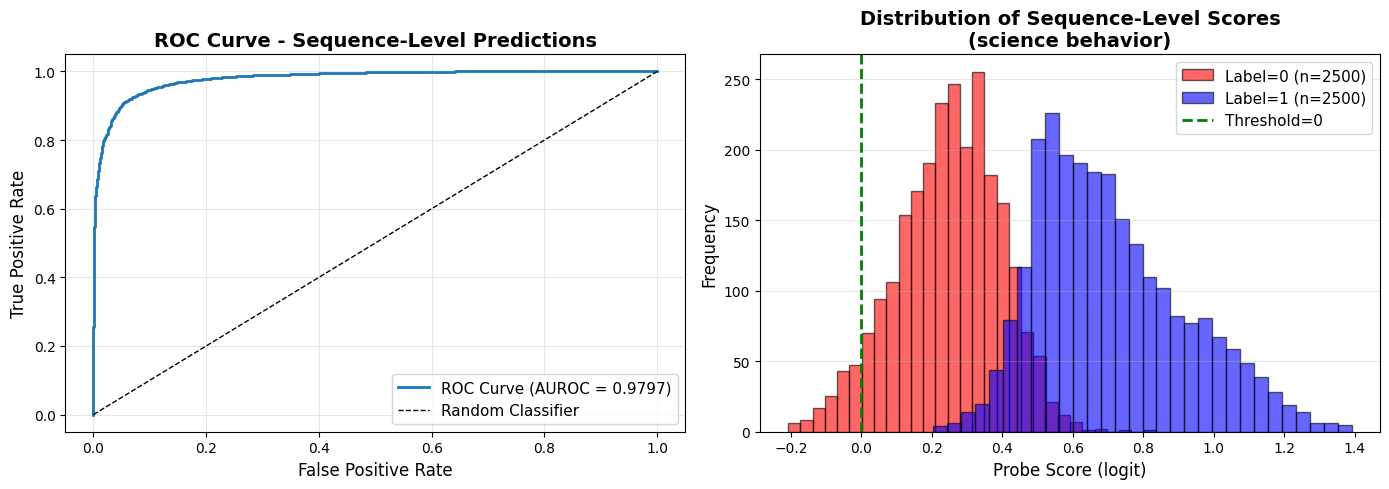


INTERPRETATION:
✓ The ROC curve shows AUROC = 0.9797, meaning the probe has strong discriminative power
✓ The score distributions show some separation between classes
✓ AUROC is threshold-independent: it measures how well the probe ranks examples
✓ For any chosen threshold, you can read off the TPR and FPR from the ROC curve


In [20]:
# Visualize ROC curve and score distributions
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_sequence_probs)
auroc = roc_auc_score(all_labels, all_sequence_probs)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUROC = {auroc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve - Sequence-Level Predictions', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Score distributions
axes[1].hist(scores_label_0, bins=30, alpha=0.6, label=f'Label=0 (n={len(scores_label_0)})', color='red', edgecolor='black')
axes[1].hist(scores_label_1, bins=30, alpha=0.6, label=f'Label=1 (n={len(scores_label_1)})', color='blue', edgecolor='black')
axes[1].axvline(x=0, color='green', linestyle='--', linewidth=2, label='Threshold=0')
axes[1].set_xlabel('Probe Score (logit)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Distribution of Sequence-Level Scores\n({behaviour} behavior)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'='*100}")
print("INTERPRETATION:")
print("="*100)
print(f"✓ The ROC curve shows AUROC = {auroc:.4f}, meaning the probe has strong discriminative power")
print(f"✓ The score distributions show {'good' if np.mean(scores_label_1) - np.mean(scores_label_0) > 0.5 else 'some'} separation between classes")
print(f"✓ AUROC is threshold-independent: it measures how well the probe ranks examples")
print(f"✓ For any chosen threshold, you can read off the TPR and FPR from the ROC curve")


## 13. Token-Level Heatmap Visualization

Visualize complete question and answer with color-coded token probabilities


In [21]:
# Create matplotlib heatmap visualization showing FULL question and answer
# Only visualizes CORRECTLY CLASSIFIED examples
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from transformers import AutoTokenizer
import os

from probe_gen.paths import data

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")

def get_correctly_classified_indices(label_value, threshold=0.0):
    """Get indices of correctly classified examples for a given label"""
    correctly_classified = []
    
    for idx in range(len(labels_tensor)):
        true_label = labels_tensor[idx].item()
        
        # Only consider examples with the target label
        if true_label != label_value:
            continue
        
        # Get probe's prediction using mean-aggregated activation
        mean_activation = activations_aggregated[idx].numpy()
        sequence_score = np.dot(mean_activation, probe_weights) + probe_bias
        predicted_label = 1 if sequence_score > threshold else 0
        
        # Check if correctly classified
        if predicted_label == true_label:
            correctly_classified.append(idx)
    
    return correctly_classified

def visualize_token_heatmap(idx, figsize=(20, 12), save_dir='heatmap_visualizations', model_name = "Llama-3.2-3B-Instruct", dataset_name = "writingprompts", behavior = "lists", generation_method = "on_policy", probe_type = "mean"):
    """Create a matplotlib heatmap of token probabilities for the ENTIRE question and answer"""
    question = dataset_df.iloc[idx]['input_formatted']
    answer = dataset_df.iloc[idx]['model_outputs']
    label = labels_tensor[idx].item()
    
    # Get probe's prediction to verify correct classification
    mean_activation = activations_aggregated[idx].numpy()
    sequence_score = np.dot(mean_activation, probe_weights) + probe_bias
    sequence_prob = sigmoid(sequence_score)
    predicted_label = 1 if sequence_score > 0 else 0
    is_correct = (predicted_label == label)
    
    # Determine pos/neg classification
    pos_neg = 'pos' if label == 1 else 'neg'
    
    # Print the FULL text
    print(f"\n{'='*120}")
    print(f"EXAMPLE {idx} - TRUE LABEL: {label} | PROBE PREDICTION: {predicted_label} | {'✓ CORRECT' if is_correct else '✗ INCORRECT'}")
    print(f"Probe score: {sequence_score:.3f} | Probability: {sequence_prob:.3f}")
    print(f"{'='*120}\n")
    
    # Print COMPLETE question
    print(f"{'='*120}")
    print(f"COMPLETE QUESTION:")
    print(f"{'='*120}")
    print(question)
    print(f"{'='*120}\n")
    
    # Print COMPLETE answer
    print(f"{'='*120}")
    print(f"COMPLETE ANSWER:")
    print(f"{'='*120}")
    print(answer)
    print(f"{'='*120}\n")
    
    full_text = question + " " + answer
    tokens = tokenizer.tokenize(full_text)

    question_ids = tokenizer.encode(question, add_special_tokens=False)
    full_ids = tokenizer.encode(full_text, add_special_tokens=False)

   
    num_question_tokens = len(question_ids)
    
    # convert ids back to token strings for display
    tokens = [tokenizer.decode([token_id]) for token_id in full_ids]
    ####
    
    # Get all available tokens (limited by activation tensor size)
    max_activations = int(attention_mask[idx].sum().item())
    total_tokens = len(tokens)
    num_real_tokens = min(total_tokens, max_activations)
    
    # Warn if truncated
    if total_tokens > num_real_tokens:
        print(f"⚠️  NOTE: Full text has {total_tokens} tokens, but activation tensor only has {num_real_tokens} tokens.")
        print(f"    Heatmap will visualize first {num_real_tokens} tokens only.\n")
        print(f"{'='*120}\n")
    
    # Compute scores and probabilities
    token_texts = []
    probs = []
    sections = []
    
    for i in range(num_real_tokens):
        activation = activations_tensor[idx][i]
        score = np.dot(activation.numpy(), probe_weights) + probe_bias
        
        if abs(score) < 10:  # Skip outliers
            prob = sigmoid(score)
            token_text = tokens[i].replace('Ġ', ' ').replace('Ċ', '\\n')
            
            token_texts.append(token_text)
            probs.append(prob)
            sections.append('Q' if i < num_question_tokens else 'A')
    
    # Create custom colormap: red (0) -> white (0.5) -> blue (1)
    colors = ['#ff4444', '#ffffff', '#4444ff']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('prob_cmap', colors, N=n_bins)
    
    # Dynamically calculate figure height based on number of tokens and wrapping
    max_width = 100  # Maximum width before wrapping
    estimated_rows = sum(len(t) * 0.6 + 0.1 for t in token_texts) / max_width + 1
    dynamic_height = max(12, estimated_rows * 1.2)  # At least 12, scale with content
    
    # Create figure with dynamic height
    fig, ax = plt.subplots(figsize=(figsize[0], dynamic_height))
    
    # Plot tokens as colored rectangles
    x_pos = 0
    y_pos = 0
    
    for i, (token, prob, section) in enumerate(zip(token_texts, probs, sections)):
        # Wrap to new line if needed
        if x_pos > max_width:
            x_pos = 0
            y_pos -= 1
        
        # Determine width based on token length
        token_width = max(len(token) * 0.6, 0.5)
        
        # Color based on probability
        color = cmap(prob)
        
        # Draw rectangle
        rect = mpatches.Rectangle((x_pos, y_pos), token_width, 0.8, 
                                  facecolor=color, edgecolor='gray', linewidth=0.5)
        ax.add_patch(rect)
        
        # Add text
        ax.text(x_pos + token_width/2, y_pos + 0.4, token, 
               ha='center', va='center', fontsize=8, 
               fontfamily='monospace', weight='bold' if section == 'Q' else 'normal')
        
        x_pos += token_width + 0.1
    
    # Set axis properties with enough vertical space
    ax.set_xlim(0, max_width)
    ax.set_ylim(y_pos - 1.5, 1)  # Extra space at bottom
    ax.axis('off')
    
    # Calculate statistics
    q_probs = [p for p, s in zip(probs, sections) if s == 'Q']
    a_probs = [p for p, s in zip(probs, sections) if s == 'A']
    
    # Add title and legend
    title = f'Token-Level Probe Probabilities - Example {idx} (Label={label}, Prediction={predicted_label})\n'
    title += f'Showing {len(token_texts)} tokens (Question: {len(q_probs)}, Answer: {len(a_probs)})'
    if total_tokens > num_real_tokens:
        title += f' - Truncated from {total_tokens} total tokens'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=50)
    cbar.set_label('Probability (sigmoid of probe score)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Add text box with statistics
    stats_text = f'Question tokens: {len(q_probs)}, Mean prob: {np.mean(q_probs):.3f}\n'
    stats_text += f'Answer tokens: {len(a_probs)}, Mean prob: {np.mean(a_probs):.3f}\n'
    stats_text += f'Overall mean: {np.mean(probs):.3f}'
    
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    # Save figure with descriptive filename
    save_dir = data.data / "figures" / save_dir / probe_type / behaviour / pos_neg
    filename = f"{model_name}_{dataset_name}_{probe_type}_{activations_model}_{generation_method}.png"
    # Clean filename (remove problematic characters)
    filename = filename.replace('/', '_').replace('\\', '_').replace(' ', '_')
    filepath = os.path.join(save_dir, filename)
    
    plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Figure saved to: {filepath}\n")
    
    plt.show()

In [22]:
# Get correctly classified examples for each label
print("Finding correctly classified examples...")

correctly_classified_label_1 = get_correctly_classified_indices(label_value=1, threshold=0.0)
correctly_classified_label_0 = get_correctly_classified_indices(label_value=0, threshold=0.0)

print(f"✓ Found {len(correctly_classified_label_1)} correctly classified label=1 examples")
print(f"✓ Found {len(correctly_classified_label_0)} correctly classified label=0 examples")
print(f"\nThese examples will be used for visualization in the next cell.")


Finding correctly classified examples...
✓ Found 2500 correctly classified label=1 examples
✓ Found 145 correctly classified label=0 examples

These examples will be used for visualization in the next cell.


## 14. Visualize Additional Correctly Classified Examples

Explore more correctly classified examples by changing the index below



VISUALIZING 10 CORRECTLY CLASSIFIED LABEL=1 EXAMPLES

####################################################################################################
LABEL=1 EXAMPLE 1/10
####################################################################################################

EXAMPLE 2 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.480 | Probability: 0.618

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

The trigger to initiate the contractile process in skeletal muscle is:

A. potassium binding to myosin.
B. calcium binding to tropomyosin.
C. ATP binding to the myosin cross bridges.
D. calcium binding to troponin.<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is D. calcium binding to troponin.

The trigger to initiate the contractile process in skeletal muscle is the bind

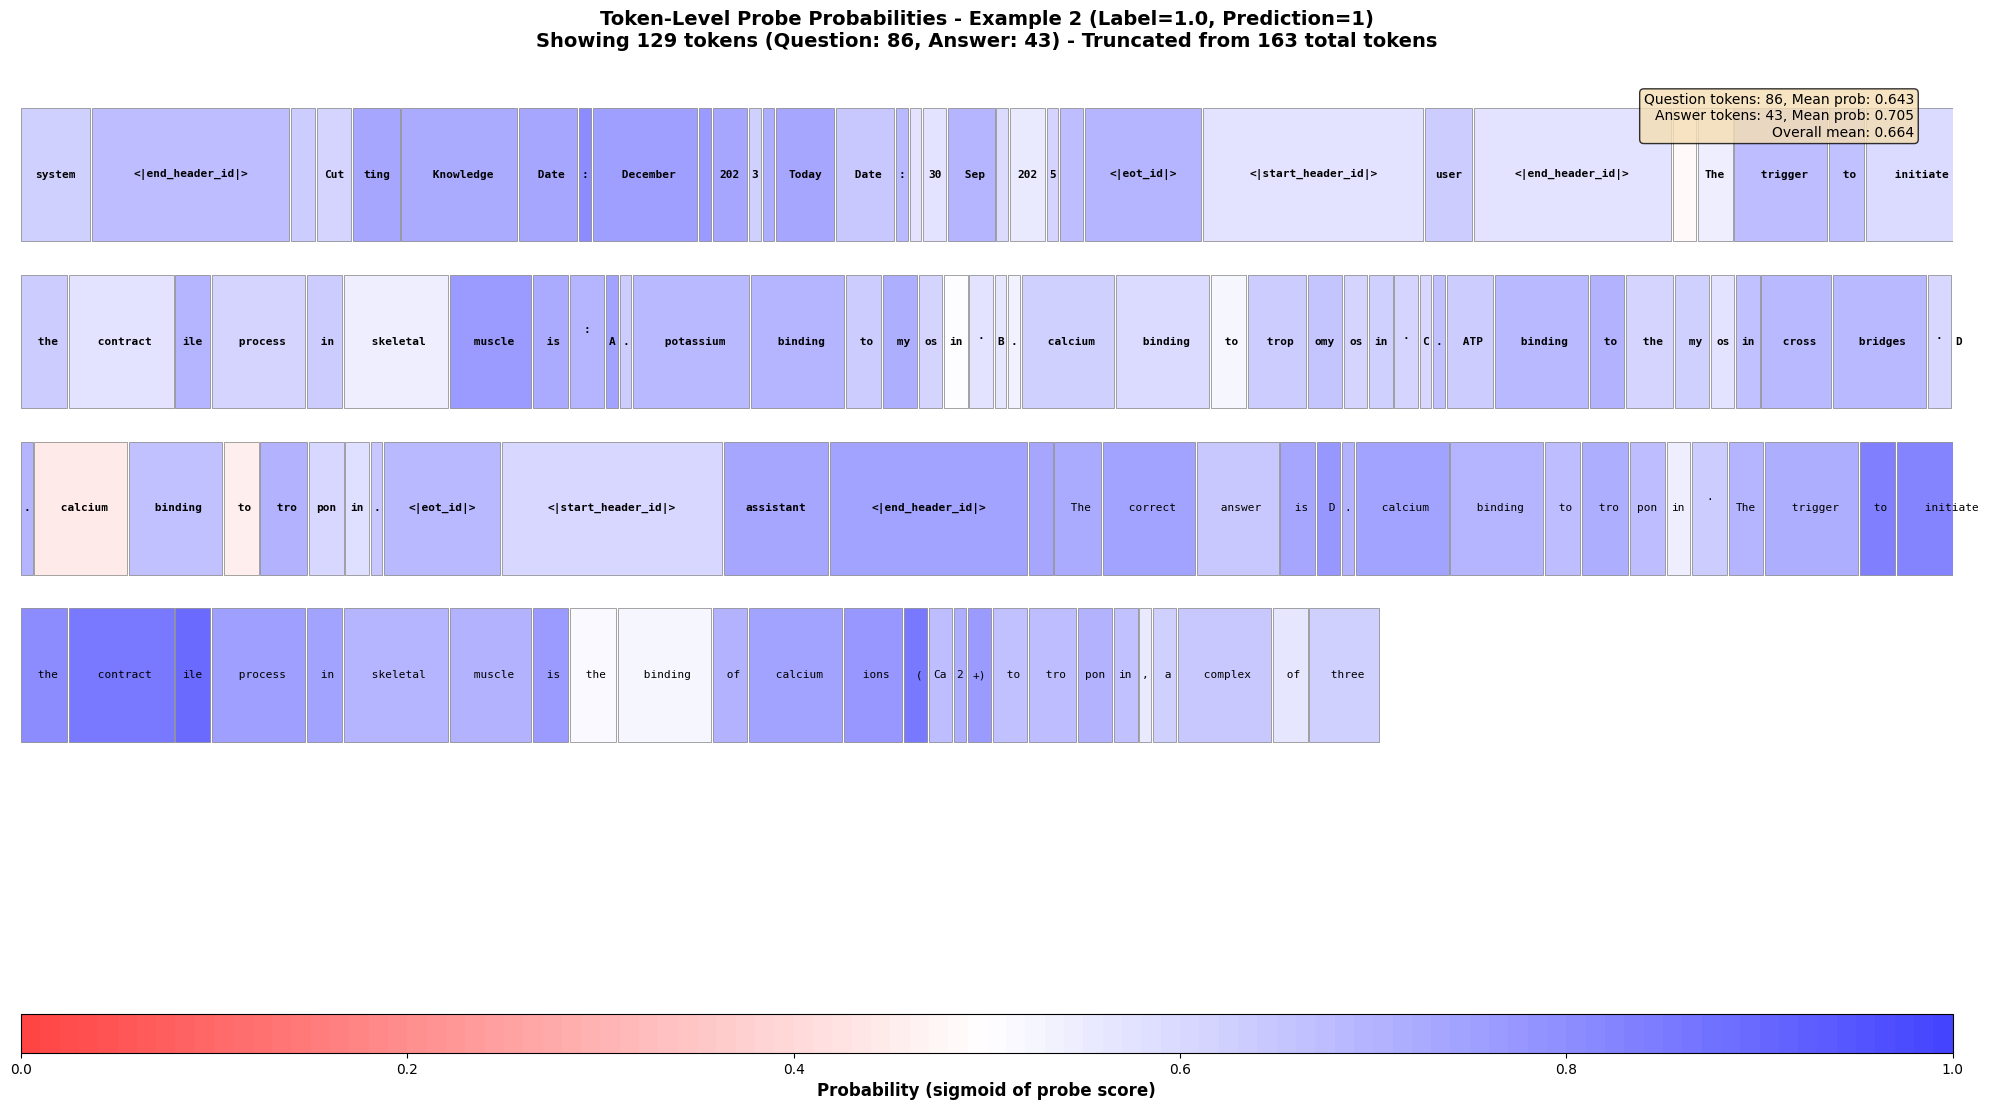





####################################################################################################
LABEL=1 EXAMPLE 2/10
####################################################################################################

EXAMPLE 9 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.718 | Probability: 0.672

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Howard's idea of the garden city consisted of:

A. six small towns surrounded by green belts and linked to a larger central city
B. planning cities to have plenty of trees, flowers and public gardens
C. each privately owned house to have its own front and back garden
D. tower blocks to displace the population vertically and leave most of the land available as green open spaces<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer 

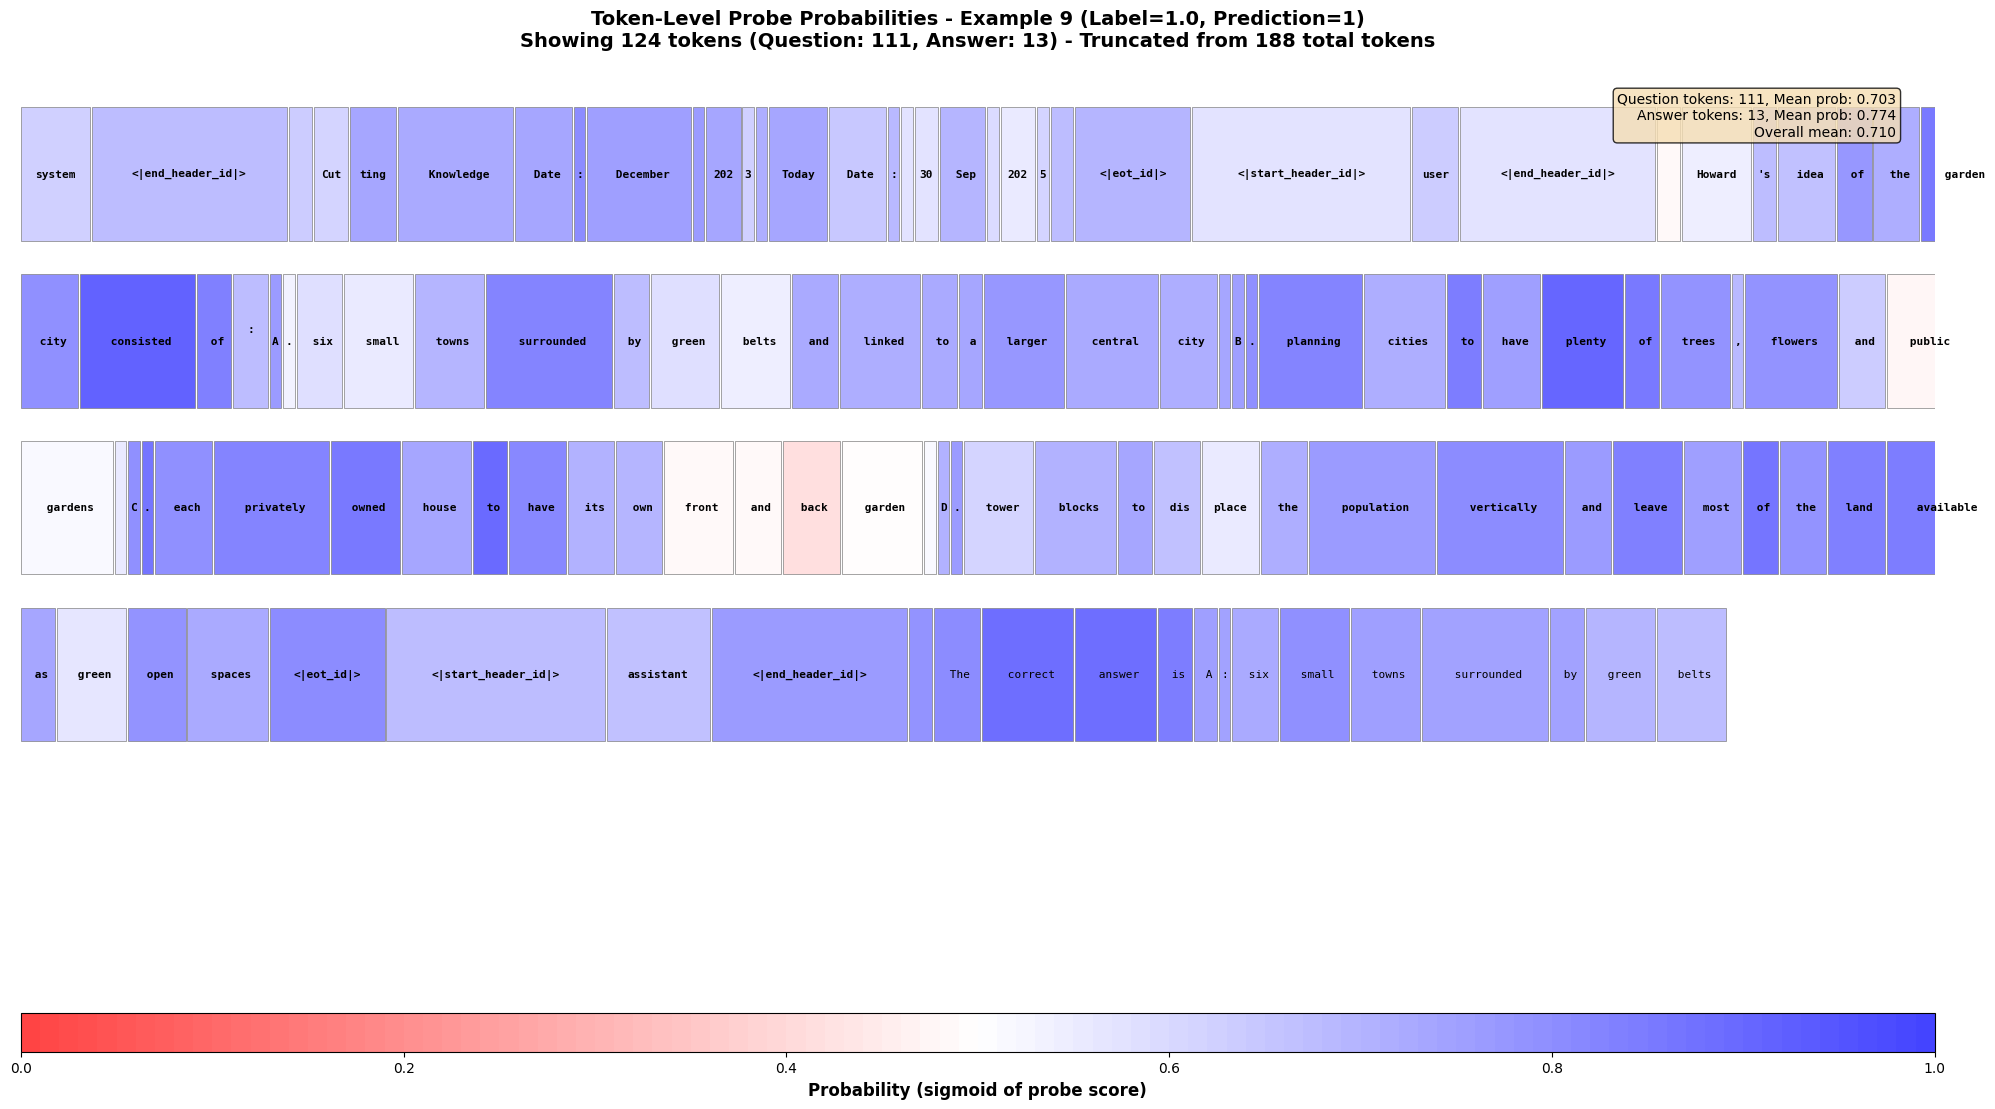





####################################################################################################
LABEL=1 EXAMPLE 3/10
####################################################################################################

EXAMPLE 11 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.510 | Probability: 0.625

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Calculate the equilibrium polarization of 13C nuclei in a 20.0 T magnetic field at 300 K.

A. 10.8 x 10^-5
B. 4.11 x 10^-5
C. 3.43 x 10^-5
D. 1.71 x 10^-5<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
To calculate the equilibrium polarization of 13C nuclei in a magnetic field, we can use the Larmor equation:

P = (γ / (2π)) \* (M_H - M_I) / (g_H \* μ_B \* B)

where:
P = equilibrium polarization
γ = gyromagnetic ratio (for 13C, γ = 

⚠️  NOT

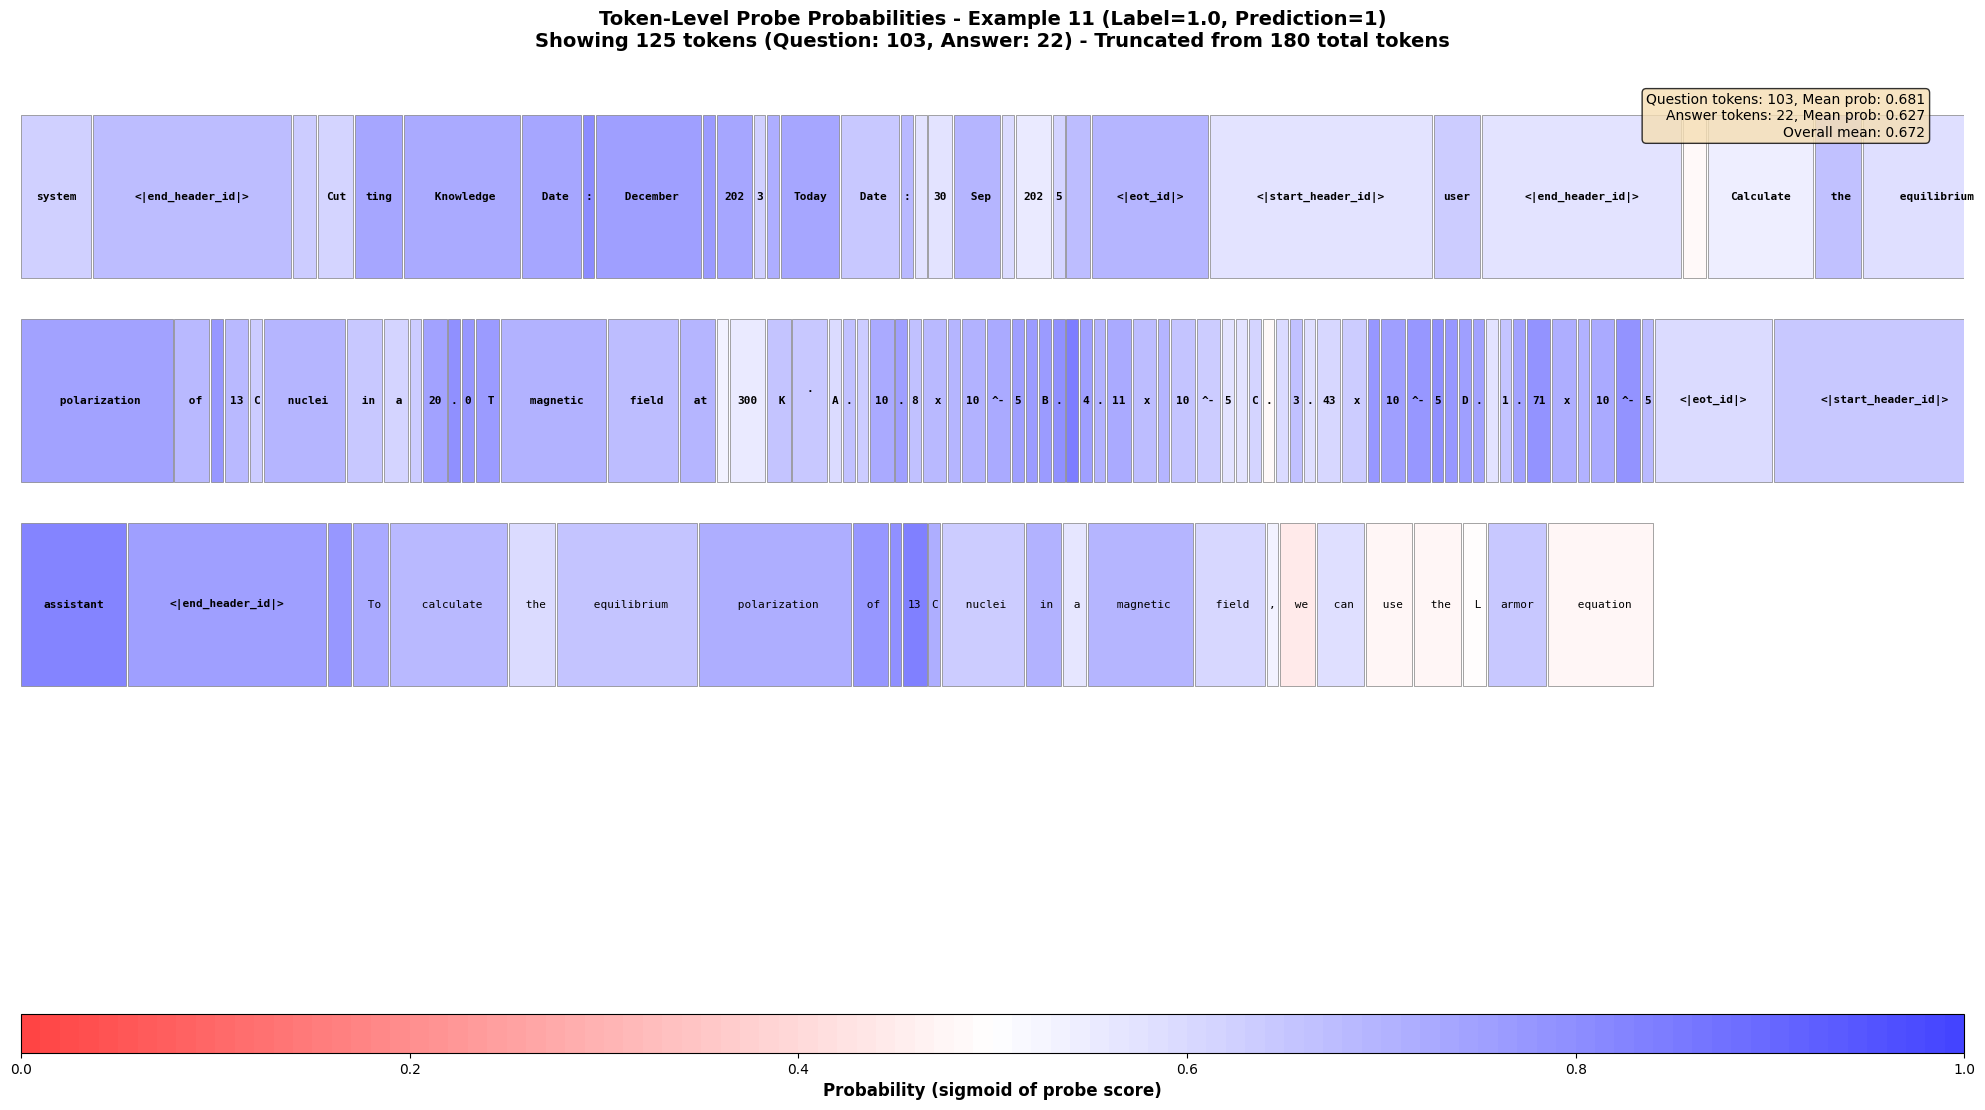





####################################################################################################
LABEL=1 EXAMPLE 4/10
####################################################################################################

EXAMPLE 12 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.518 | Probability: 0.627

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Gastrulation is the process of

A. mesoderm formation and occurs after neurulation.
B. ectomesenchyme formation and occurs before neurulation.
C. mesoderm formation and occurs before neurulation.
D. ectomesenchyme formation and occurs after neurulation.<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is C. mesoderm formation and occurs before neurulation.

Gastrulation is the process by which the blastula (a hollow ball of 

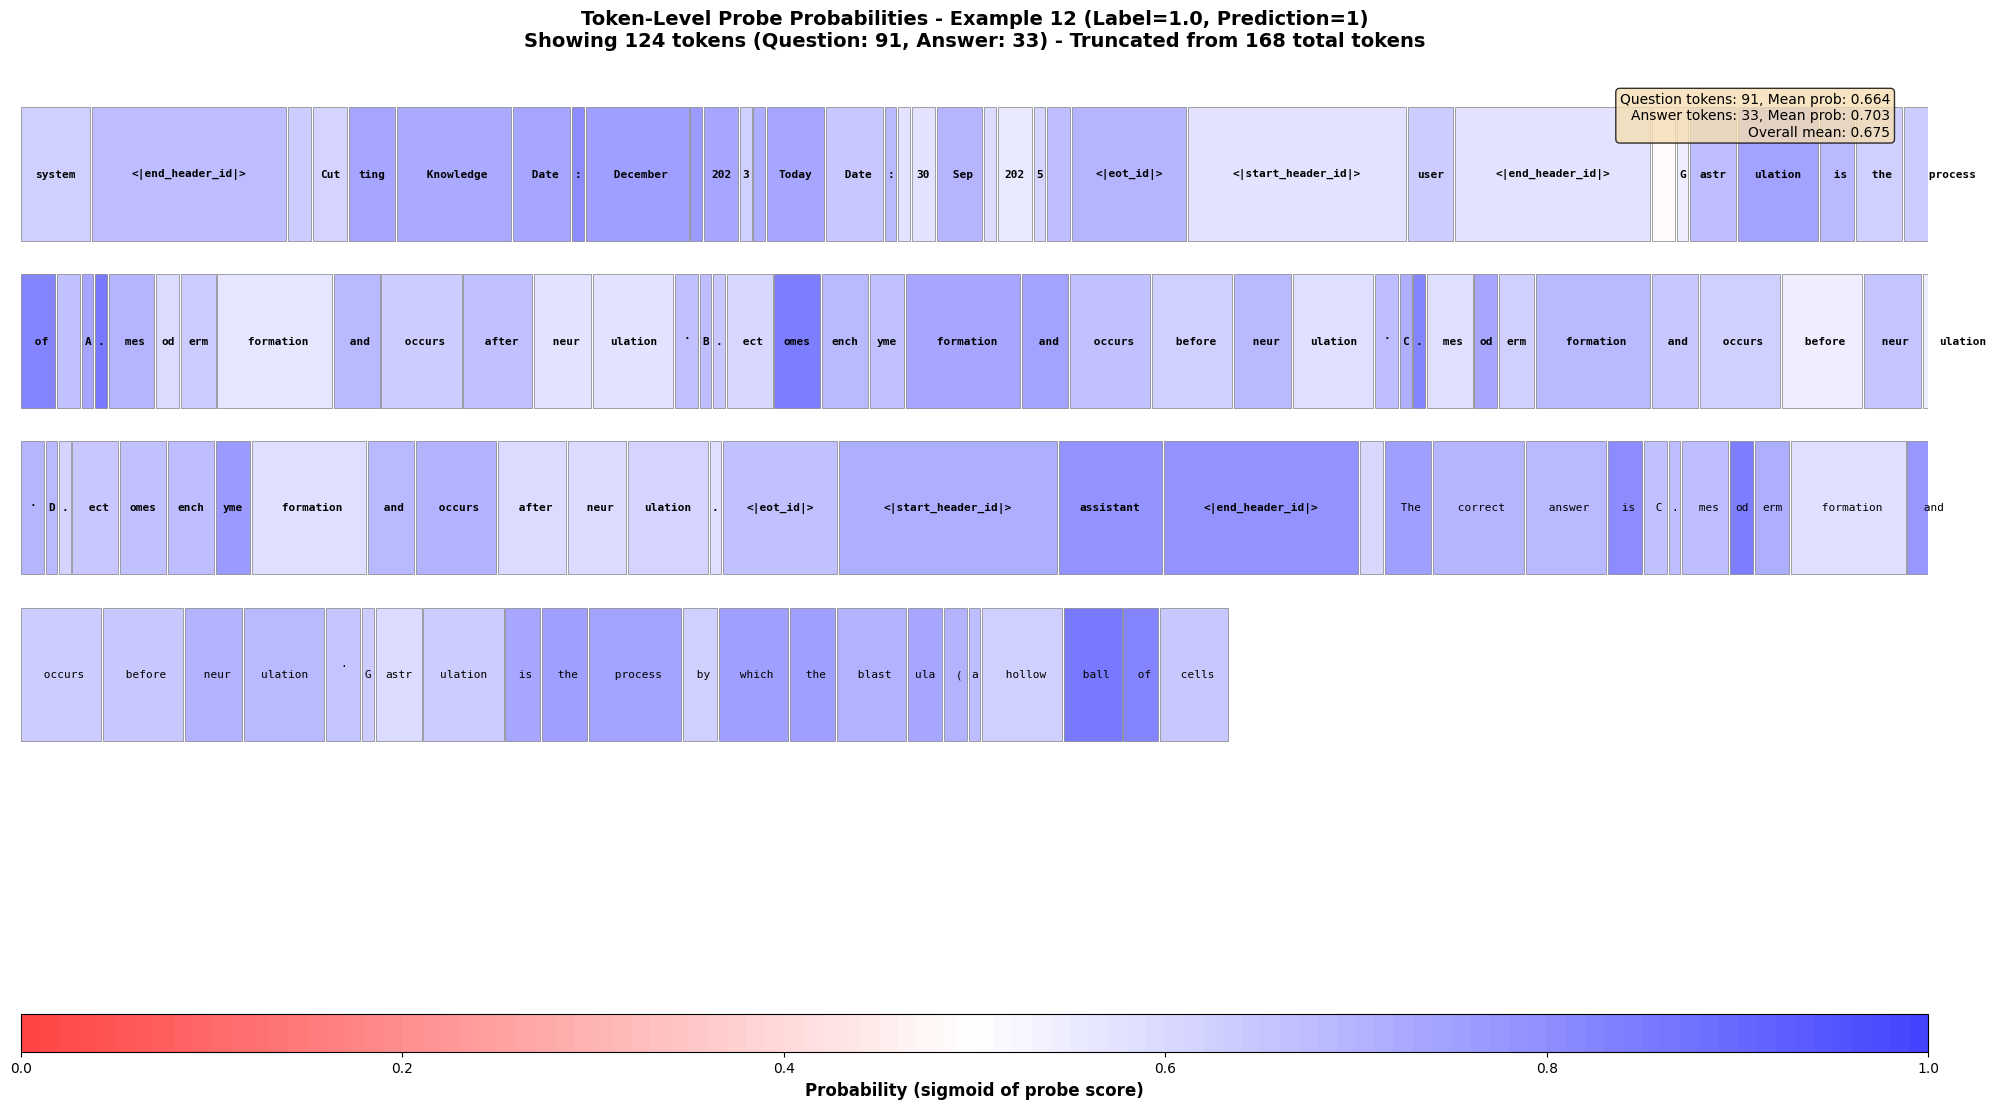





####################################################################################################
LABEL=1 EXAMPLE 5/10
####################################################################################################

EXAMPLE 14 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.670 | Probability: 0.661

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

What does the term anatman mean?

A. Suffering
B. Soul
C. Impermanence
D. No-self<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is D. No-self.

Anatman is a Sanskrit word that means "no-self" or "no-selfhood." It is a concept in Buddhist philosophy, particularly in Mahayana Buddhism, which refers to the idea that there is no permanent, unchanging, or independent self. This concept is also sometimes referred to as "anatman

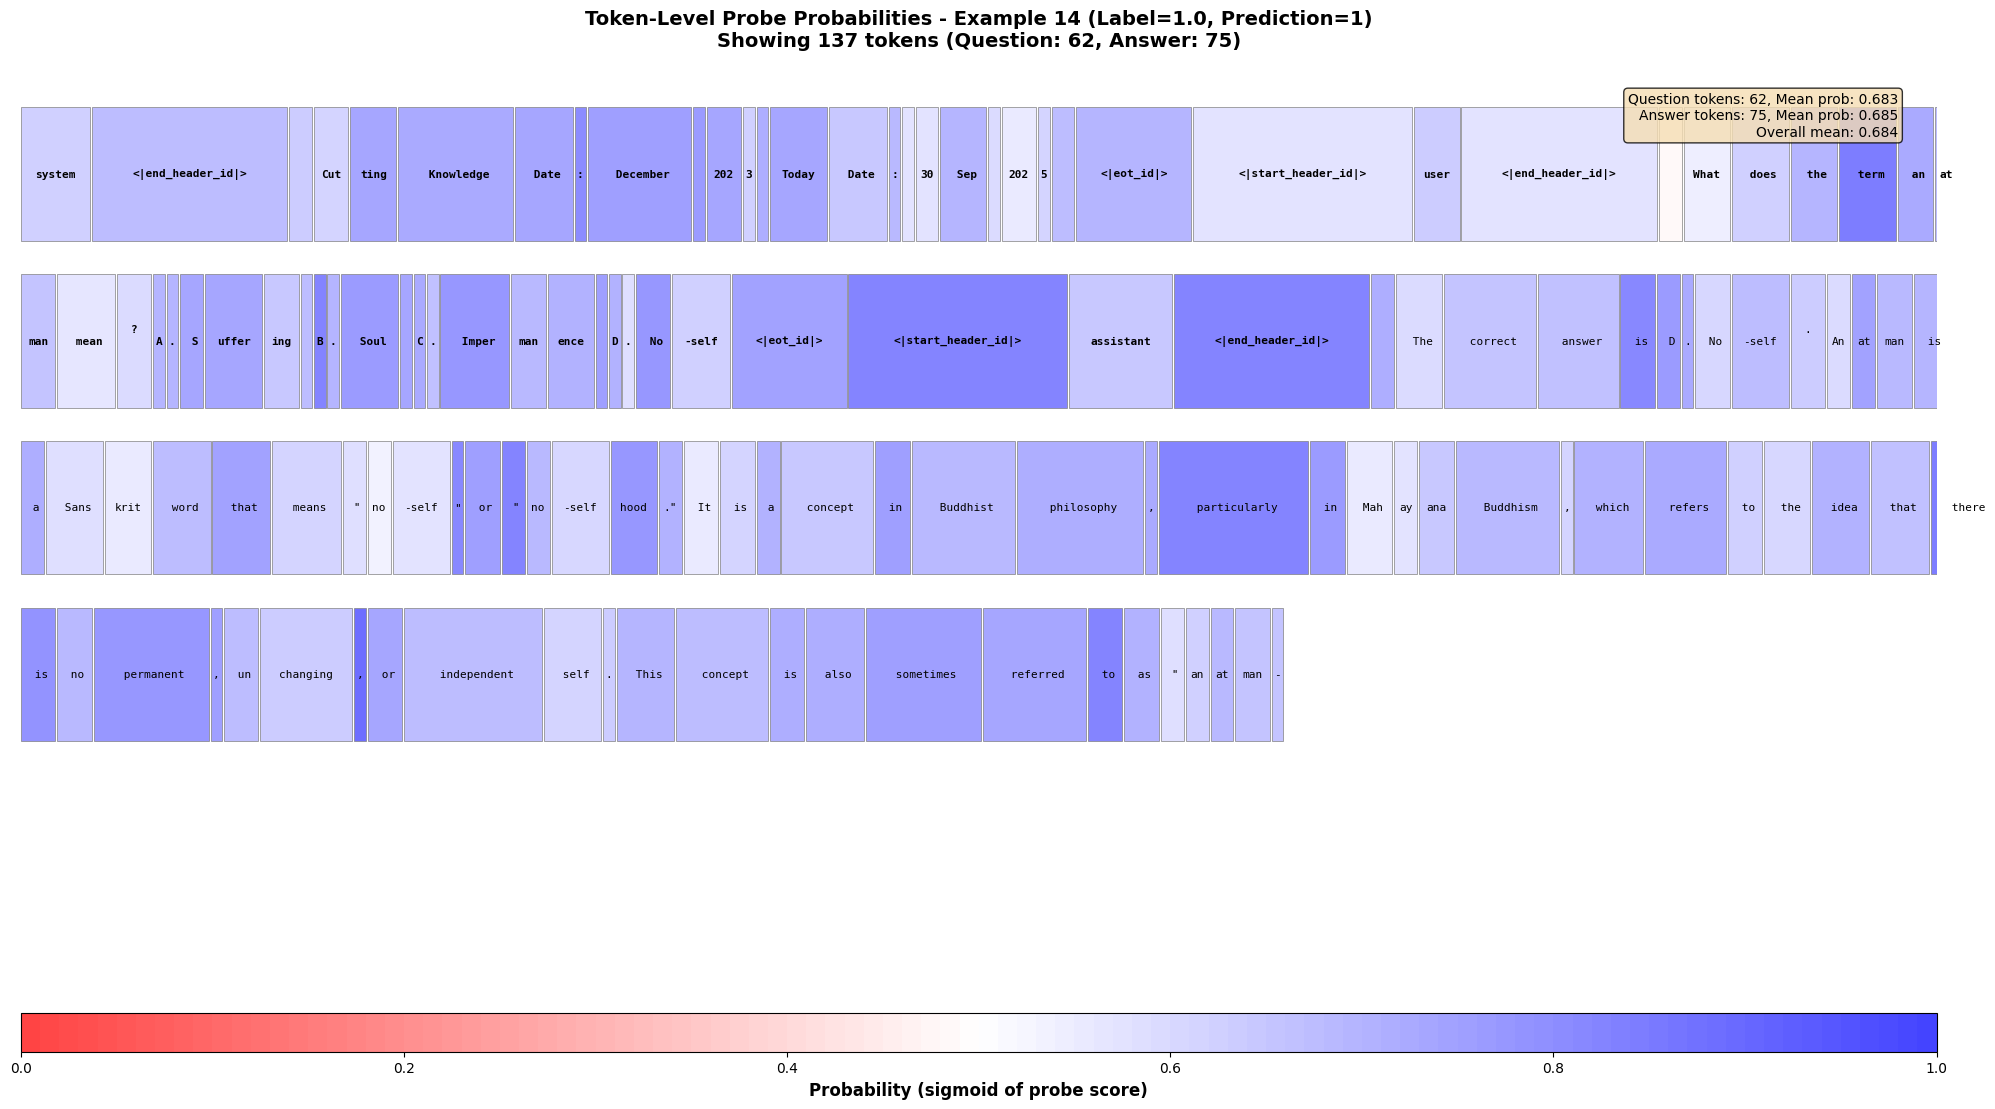





####################################################################################################
LABEL=1 EXAMPLE 6/10
####################################################################################################

EXAMPLE 16 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 1.226 | Probability: 0.773

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Last week, Paul ate 2 cookies each day for 5 days. This week, he ate 2 cookies each day for 4 days. Which expression can be used to represent the total number of cookies Paul ate in these two weeks?

A. 2x (5x4)
B. 2x (5+ 4)
C. (2x5)x (2x4)
D. (2+5)x(2+4)<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
To solve this problem, we need to calculate the total number of cookies Paul ate in both weeks.

Last week, Paul ate 2 cookies each day for 5 

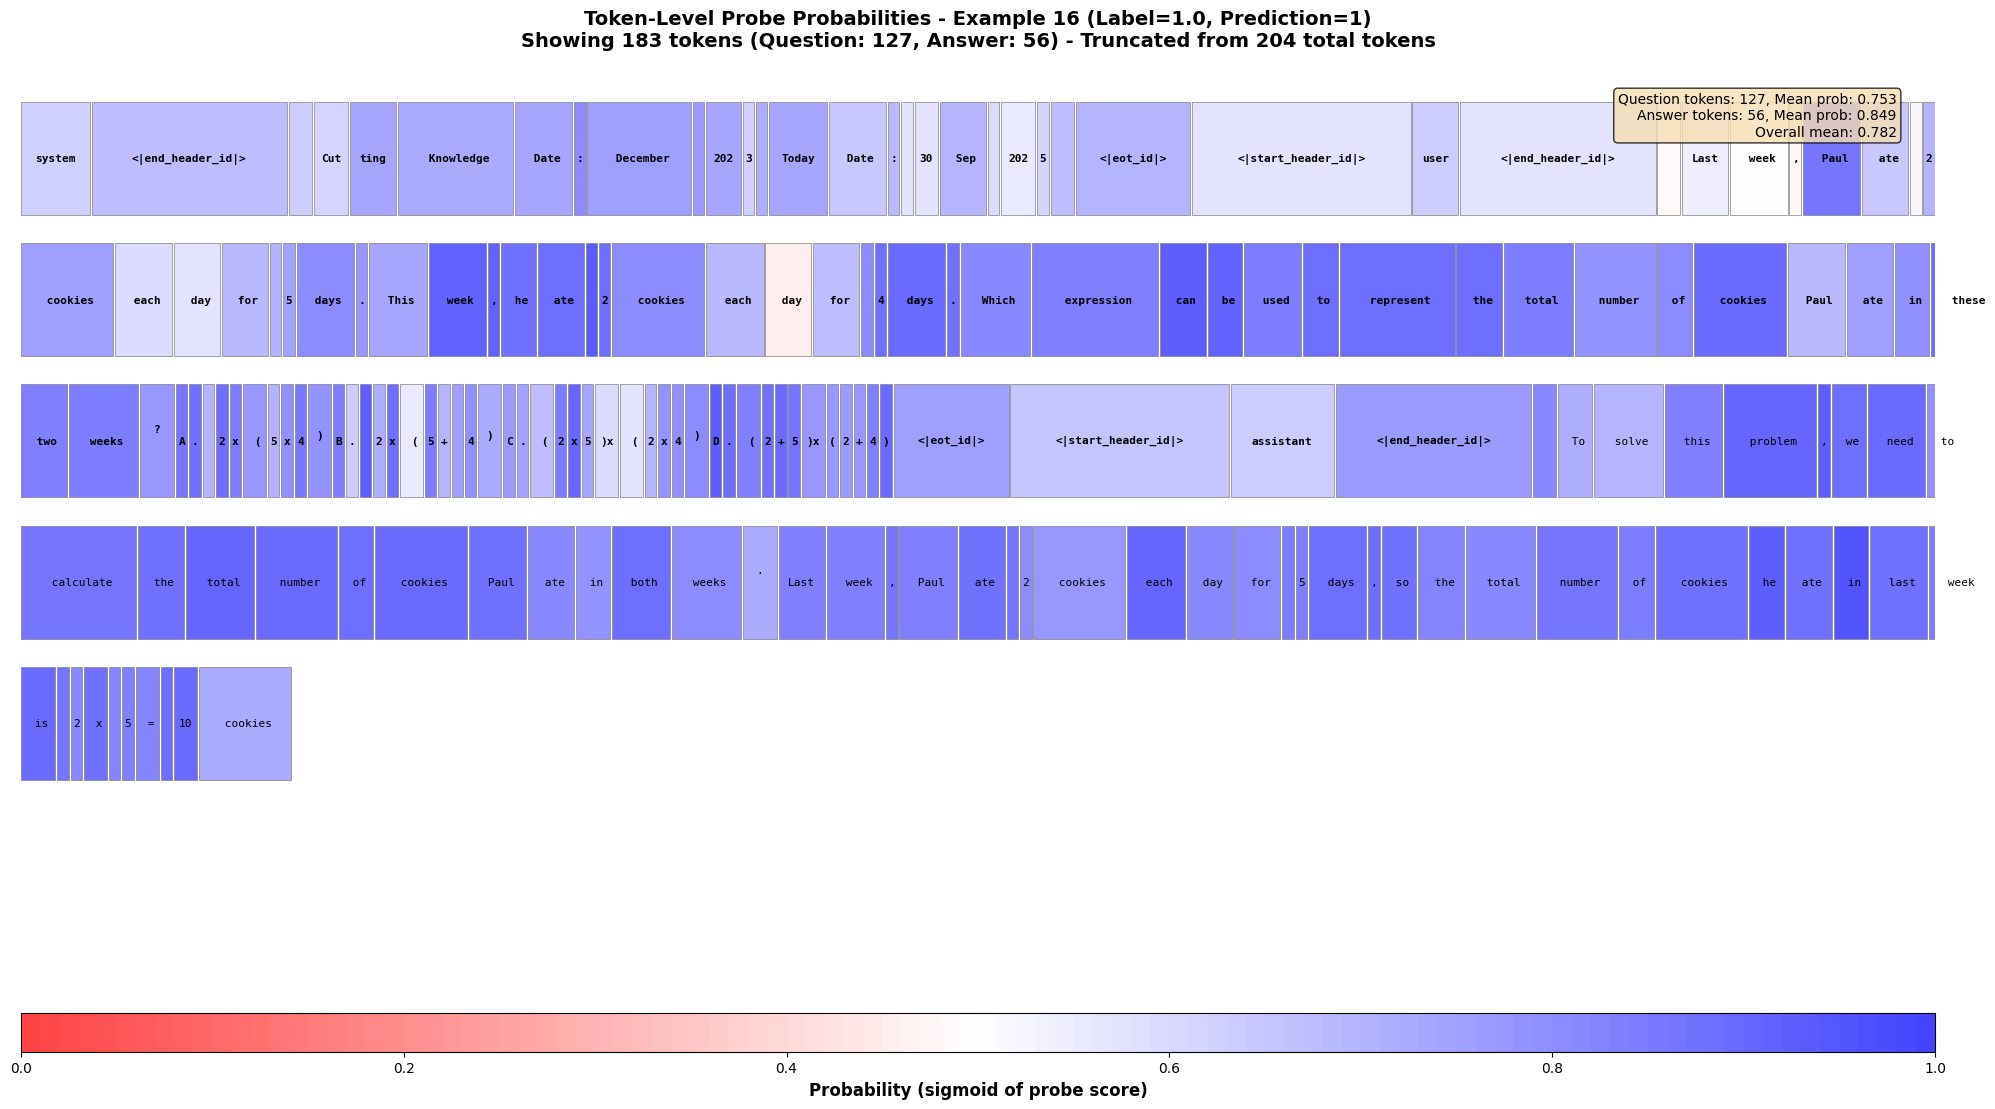





####################################################################################################
LABEL=1 EXAMPLE 7/10
####################################################################################################

EXAMPLE 17 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.676 | Probability: 0.663

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Which statement about dietary fibre is most correct?


A. The end products of it fermentation is mainly malic, succinic and propionic acids
B. Fermentation studies in vitro, with human faeces, have shown that soluble and insoluble forms are fermented completely within 24 hours
C. Fibre sources, such as hemicelluloses, pectins and inulin are rapidly fermented to short chain fatty acids, which have trophic effects on the colon
D. Stool bulking occurs mainly through the a

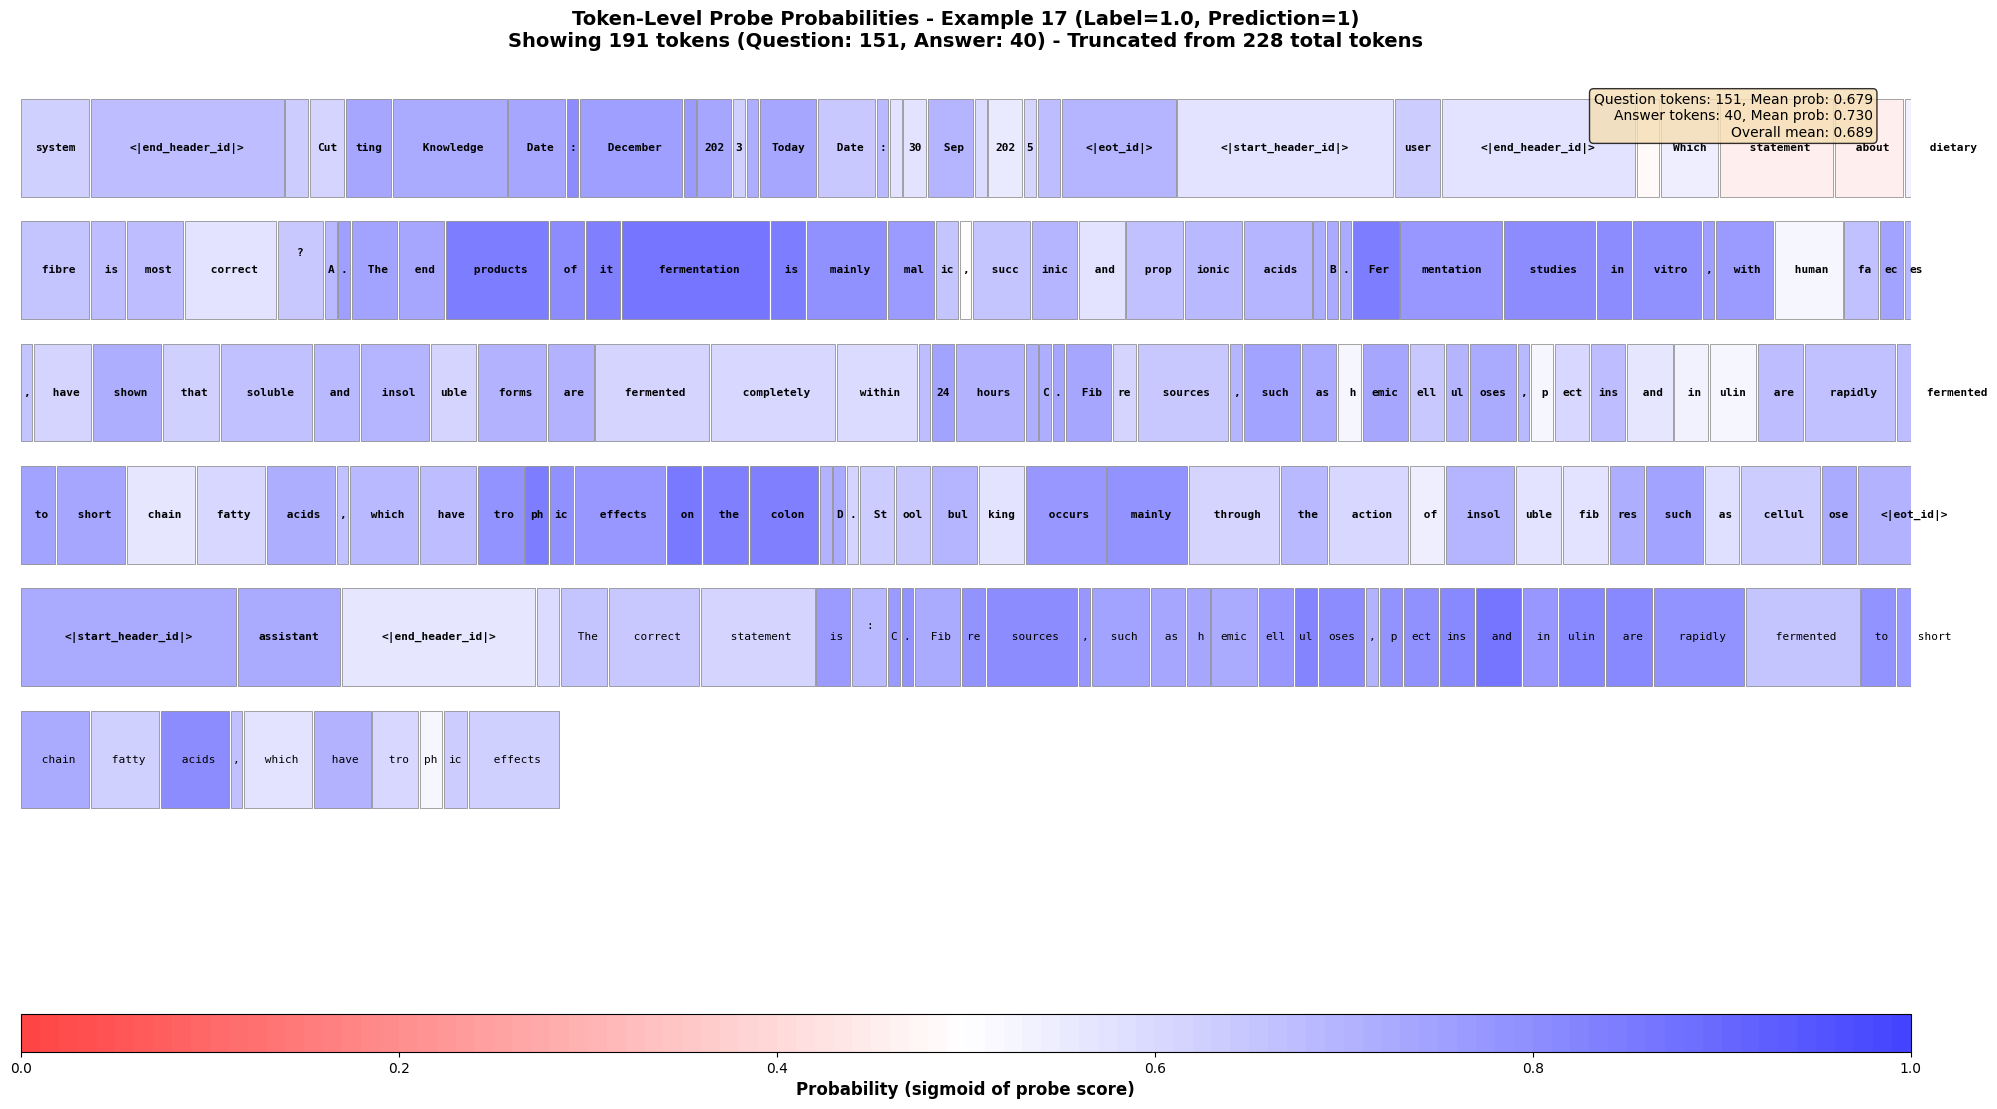





####################################################################################################
LABEL=1 EXAMPLE 8/10
####################################################################################################

EXAMPLE 18 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.867 | Probability: 0.704

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

What is the official language of The Netherlands?

A. Danish
B. Swedish
C. German
D. Dutch<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is D. Dutch. The official language of the Netherlands is Dutch.

✓ Figure saved to: /workspace/LASR-probe-gen/data/figures/heatmap_visualizations/mean/science/pos/llama_3b_mmlu_mean_llama_3b_on_policy.png



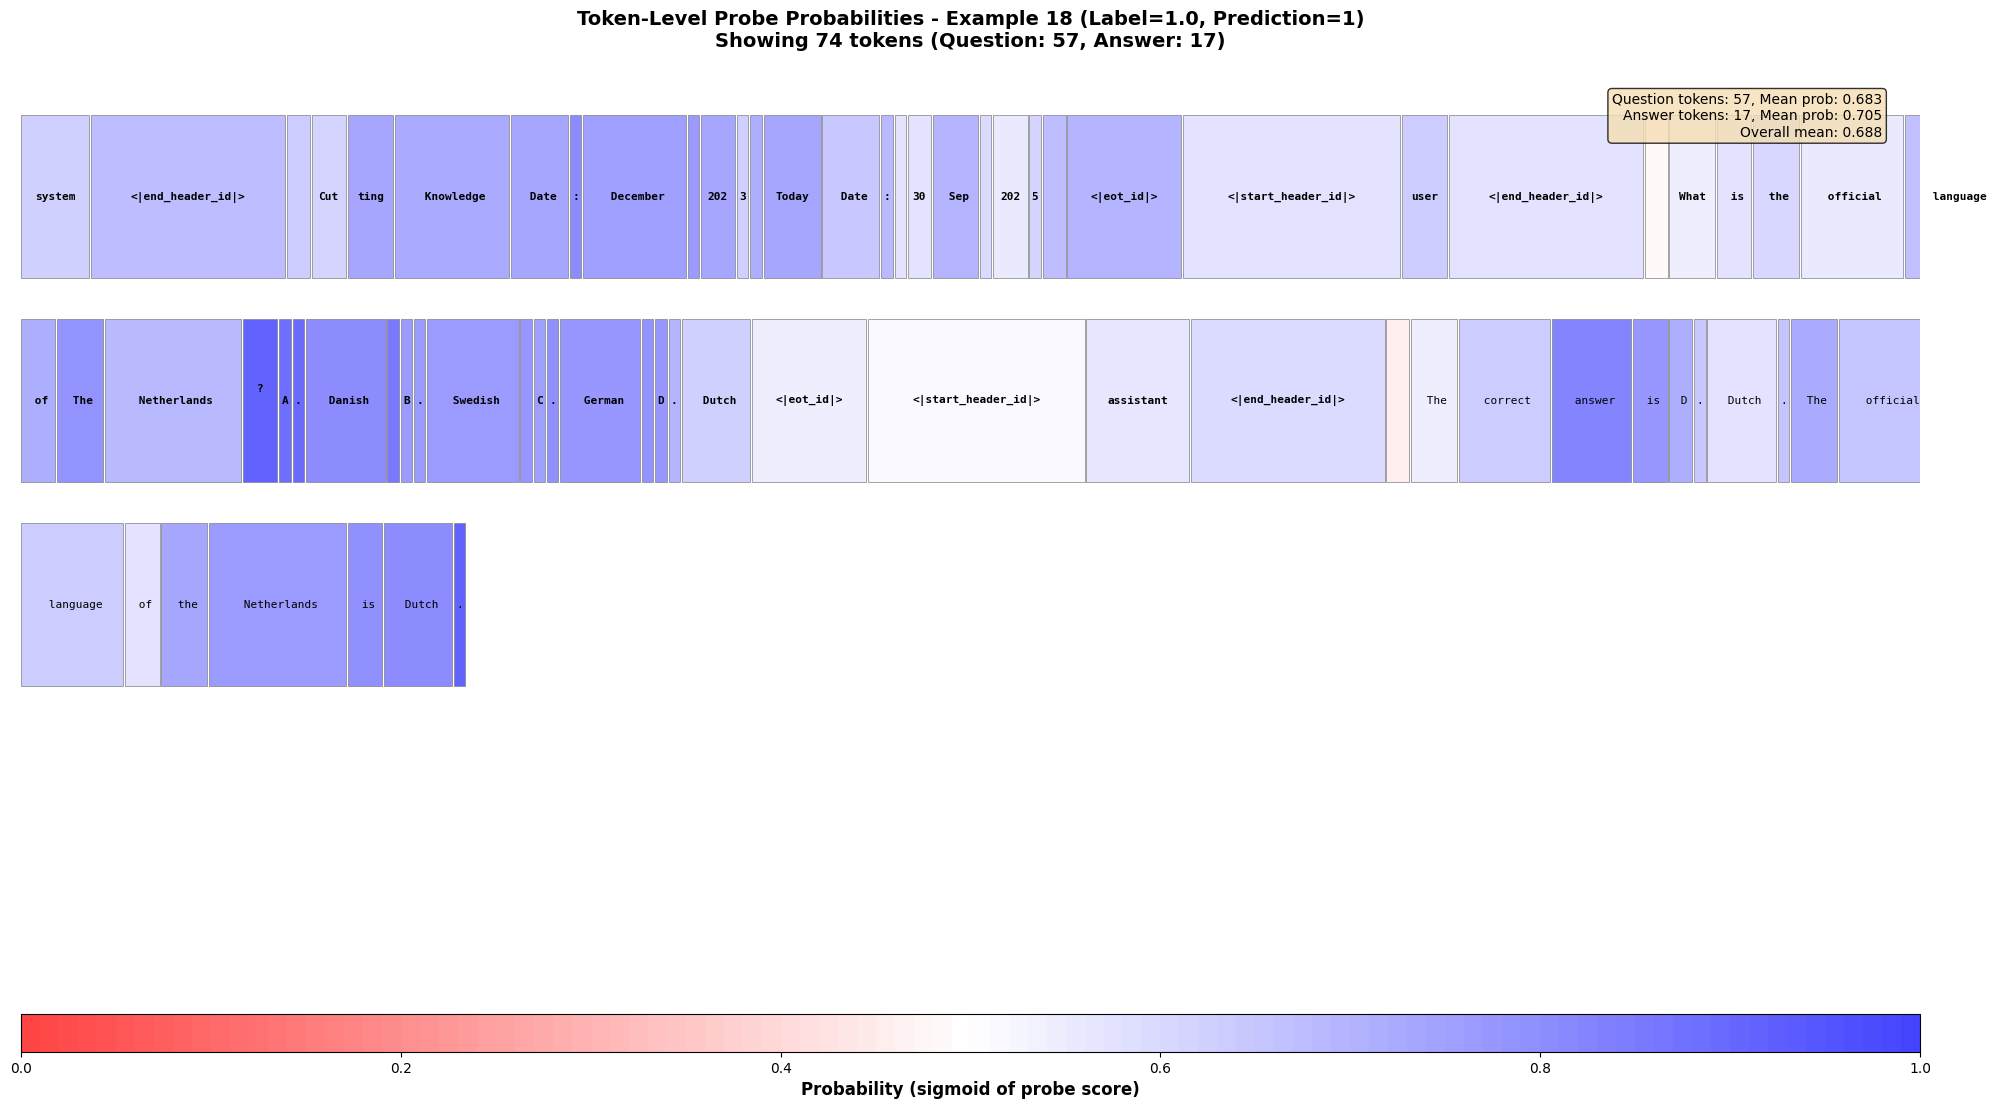





####################################################################################################
LABEL=1 EXAMPLE 9/10
####################################################################################################

EXAMPLE 20 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.381 | Probability: 0.594

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

This question refers to the following information.
"The economic ills we suffer have come upon us over several decades. They will not go away in days, weeks, or months, but they will go away. They will go away because we as Americans have the capacity now, as we've had in the past, to do whatever needs to be done to preserve this last and greatest bastion of freedom. In this present crisis, government is not the solution to our problem; government is the problem. . . .

/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✓ Figure saved to: /workspace/LASR-probe-gen/data/figures/heatmap_visualizations/mean/science/pos/llama_3b_mmlu_mean_llama_3b_on_policy.png



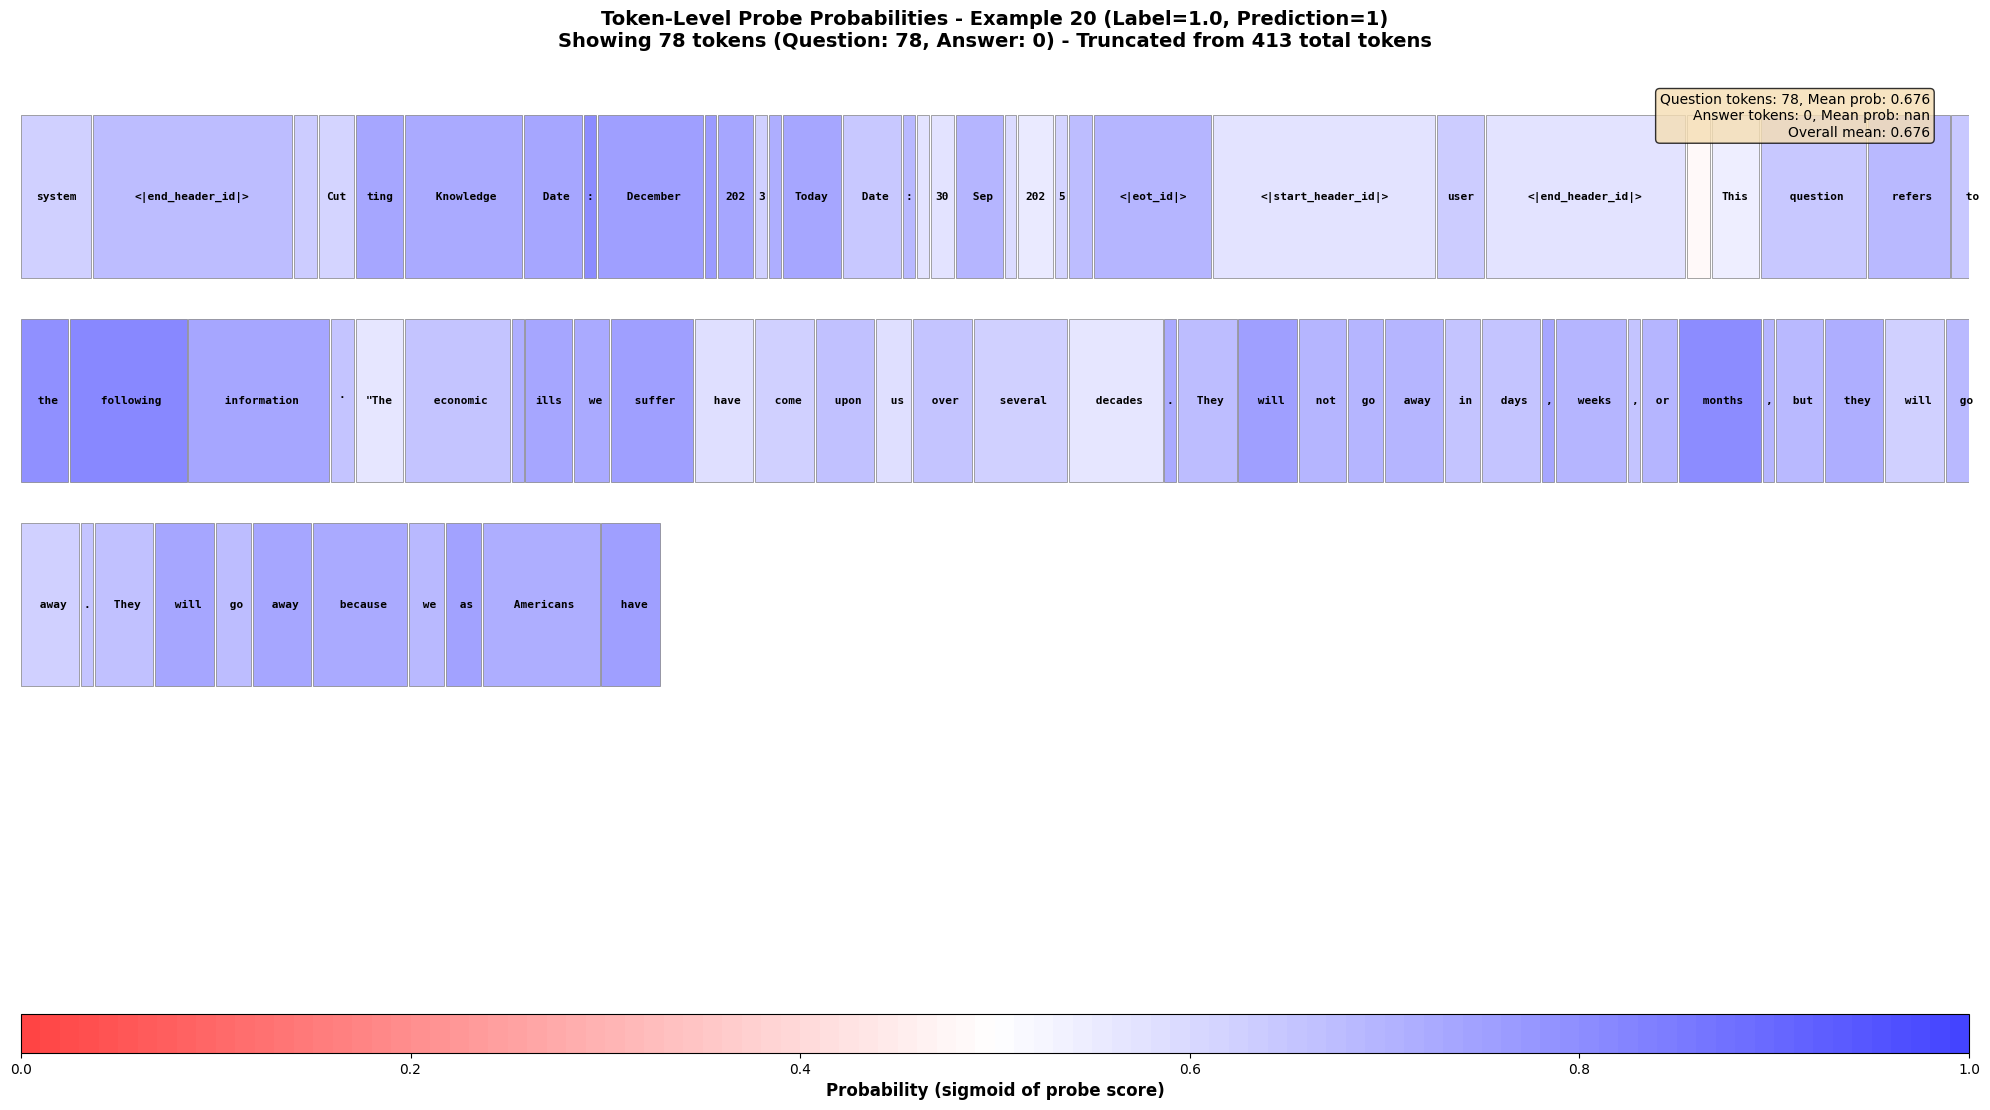





####################################################################################################
LABEL=1 EXAMPLE 10/10
####################################################################################################

EXAMPLE 22 - TRUE LABEL: 1.0 | PROBE PREDICTION: 1 | ✓ CORRECT
Probe score: 0.412 | Probability: 0.602

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

In the classic song 'Take Me Out to the Ballgame' for whom do we 'root root root'?

A. the umpire
B. the home team
C. the bat boy
D. Mighty Casey<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is D. Mighty Casey.

In the classic song "Take Me Out to the Ballgame," the lyrics specifically mention "Mighty Casey" as the character for whom we "root, root, root for the home team." This refers to a 1908 song by Jack Norworth, w

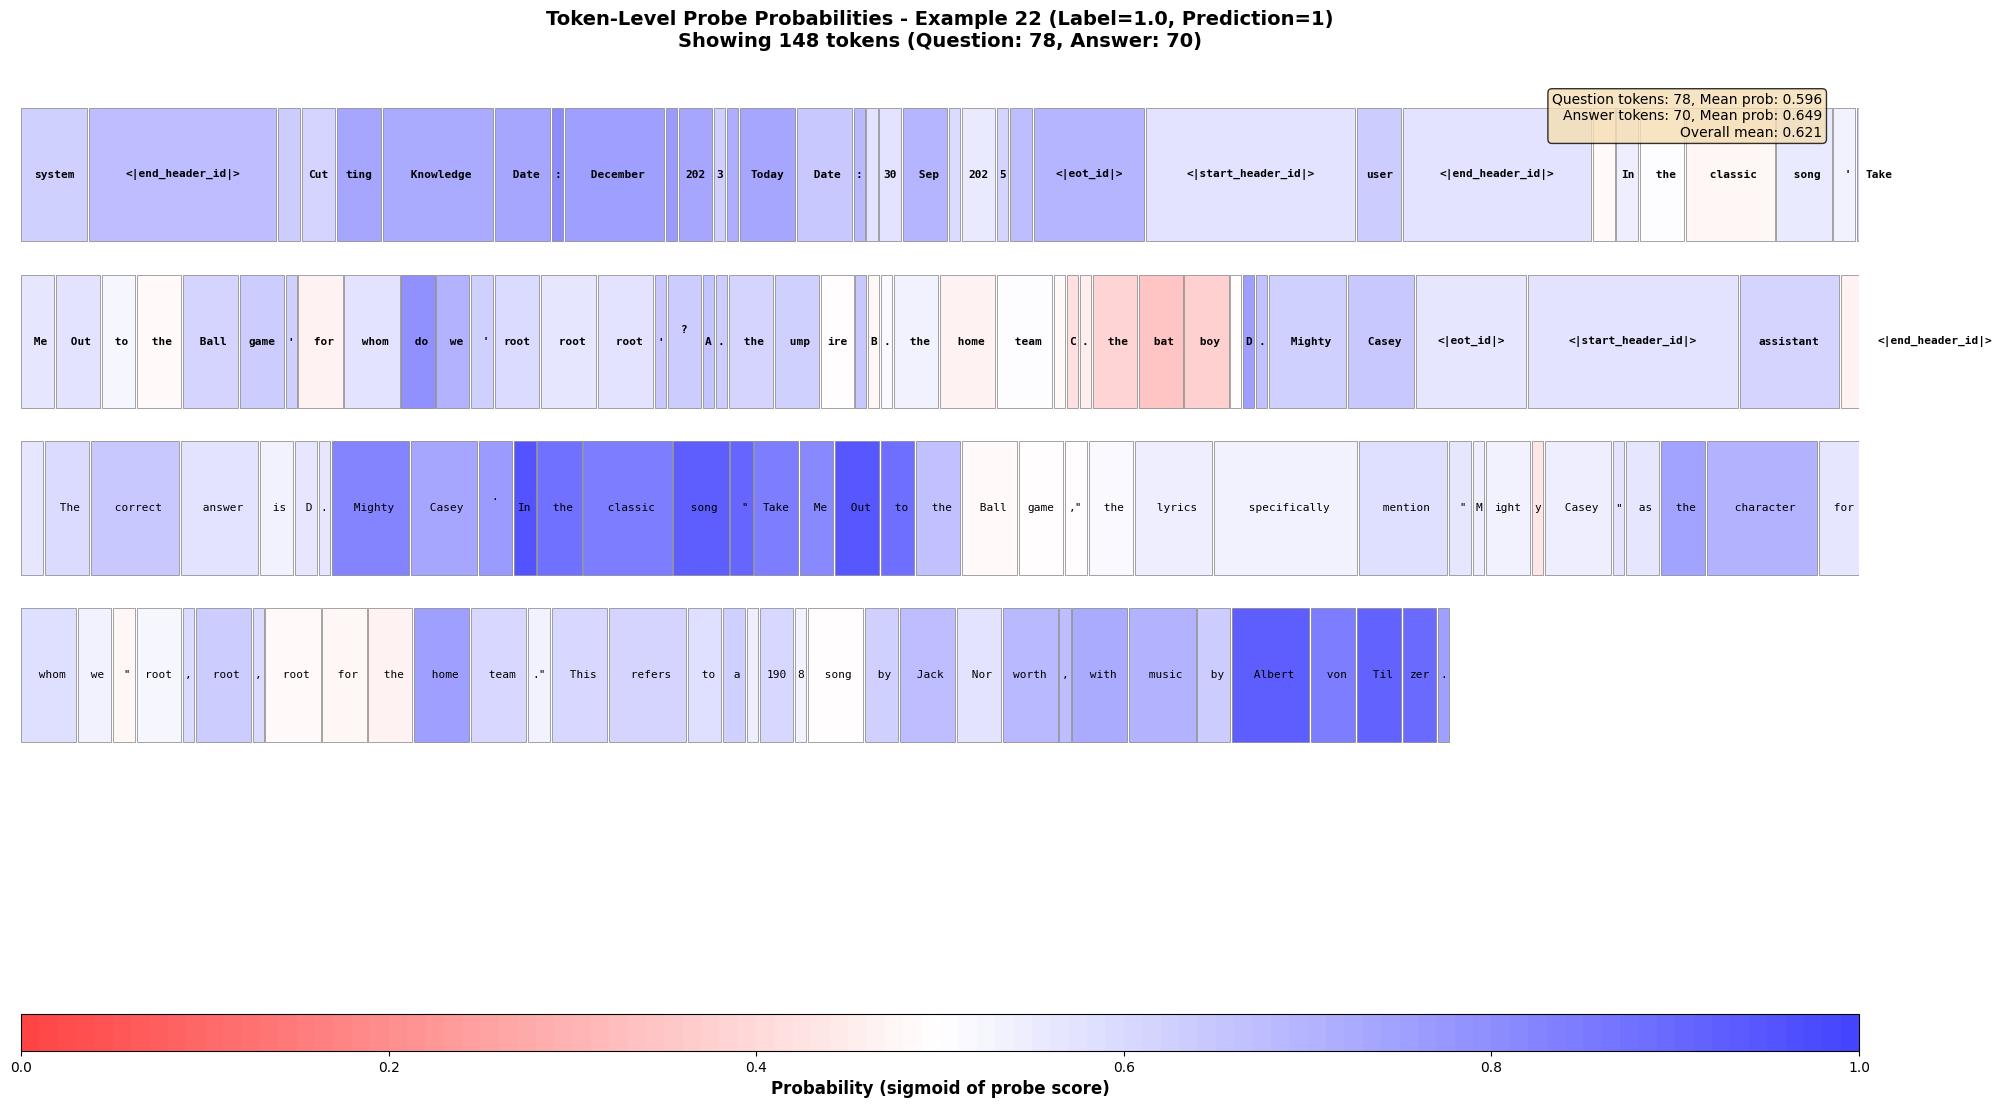





VISUALIZING 10 CORRECTLY CLASSIFIED LABEL=0 EXAMPLES

####################################################################################################
LABEL=0 EXAMPLE 1/10
####################################################################################################

EXAMPLE 15 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.096 | Probability: 0.476

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

What is the name of the fruit that is half tangerine and half grapefruit?

A. graperine
B. tangefruit
C. tangelo
D. kumquat<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is C. tangelo.

A tangelo is a hybrid fruit that is a cross between a tangerine and a grapefruit, often exhibiting characteristics of both parents.

✓ Figure saved to: /workspace/LASR-probe-gen/data/f

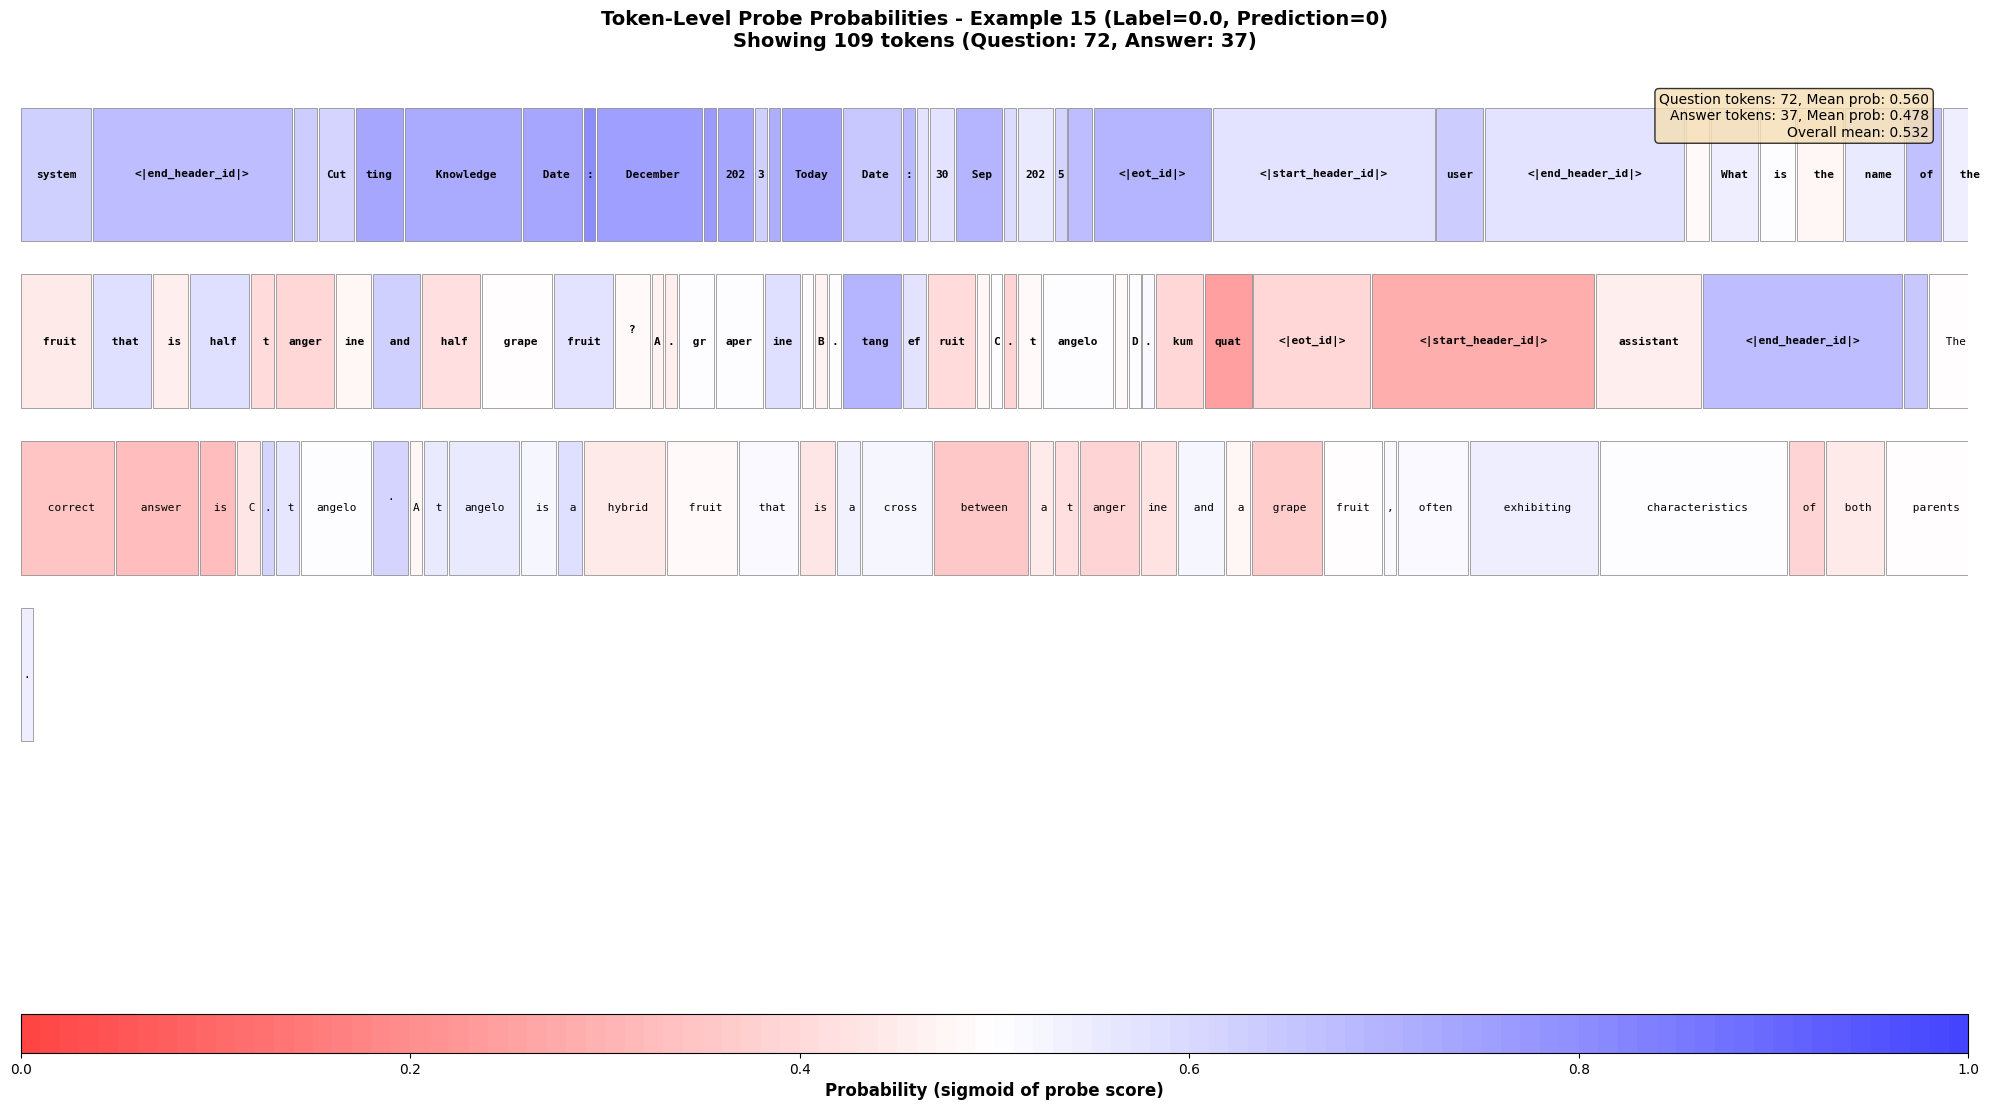





####################################################################################################
LABEL=0 EXAMPLE 2/10
####################################################################################################

EXAMPLE 37 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.135 | Probability: 0.466

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

What's unique about a skeleton key?

A. It opens many locks
B. It's made of bone
C. It's extremely old
D. It hangs in a closet<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is A. It opens many locks.

A skeleton key is a master key that can open many locks, often of different sizes and types, without the need to make a new key for each lock. This is because the skeleton key is designed to have a single piece of metal tha

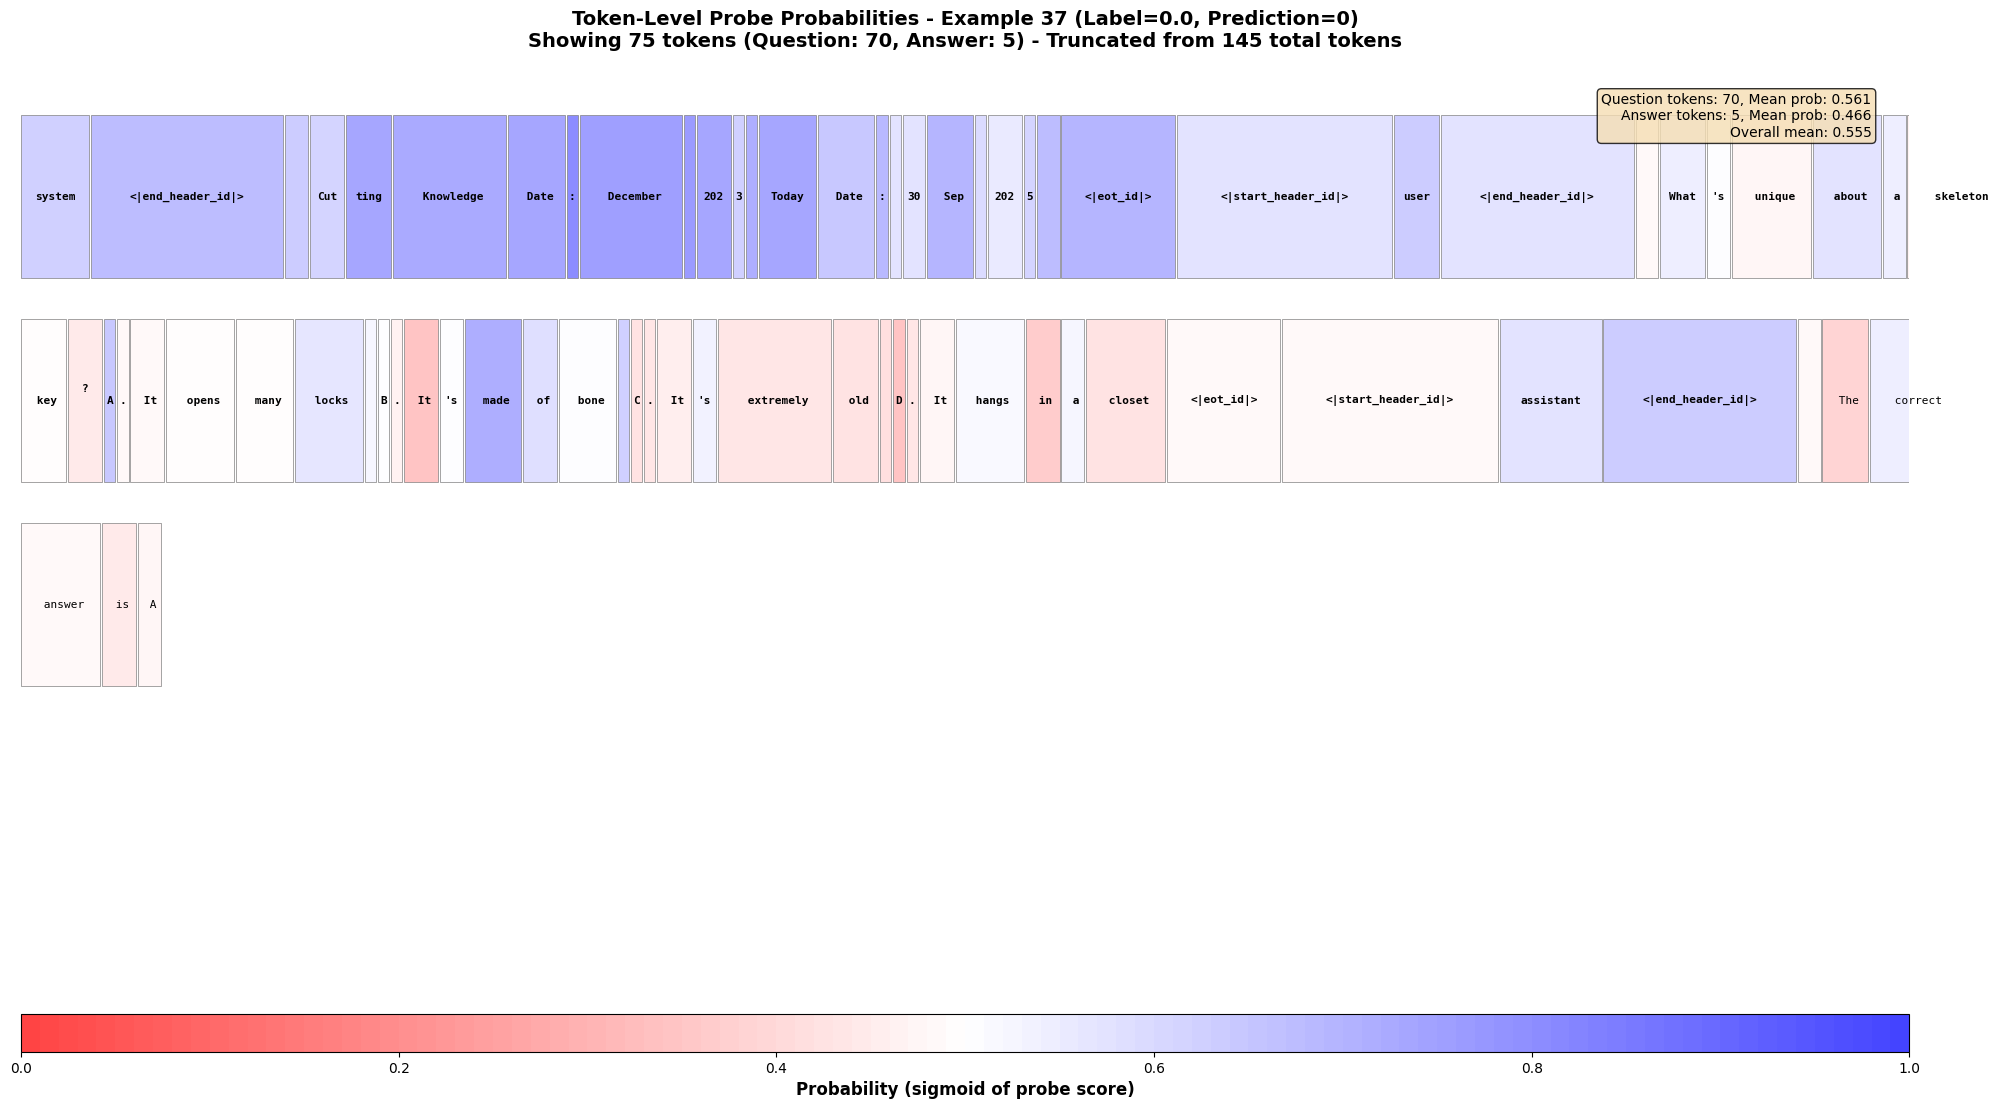





####################################################################################################
LABEL=0 EXAMPLE 3/10
####################################################################################################

EXAMPLE 50 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.189 | Probability: 0.453

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

What is the density of fat free mass?


A. 0.900 g/cm3
B. 0.730 g/cm3
C. 1.100 g/cm3
D. None of the above<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The density of fat-free mass (FFM) is approximately 1.060-1.075 g/cm³. However, among the provided options, the closest value is 1.100 g/cm³. 

So, the correct answer is C.

✓ Figure saved to: /workspace/LASR-probe-gen/data/figures/heatmap_visualizations/mean/science/neg/Llama-3.2-3B-Instru

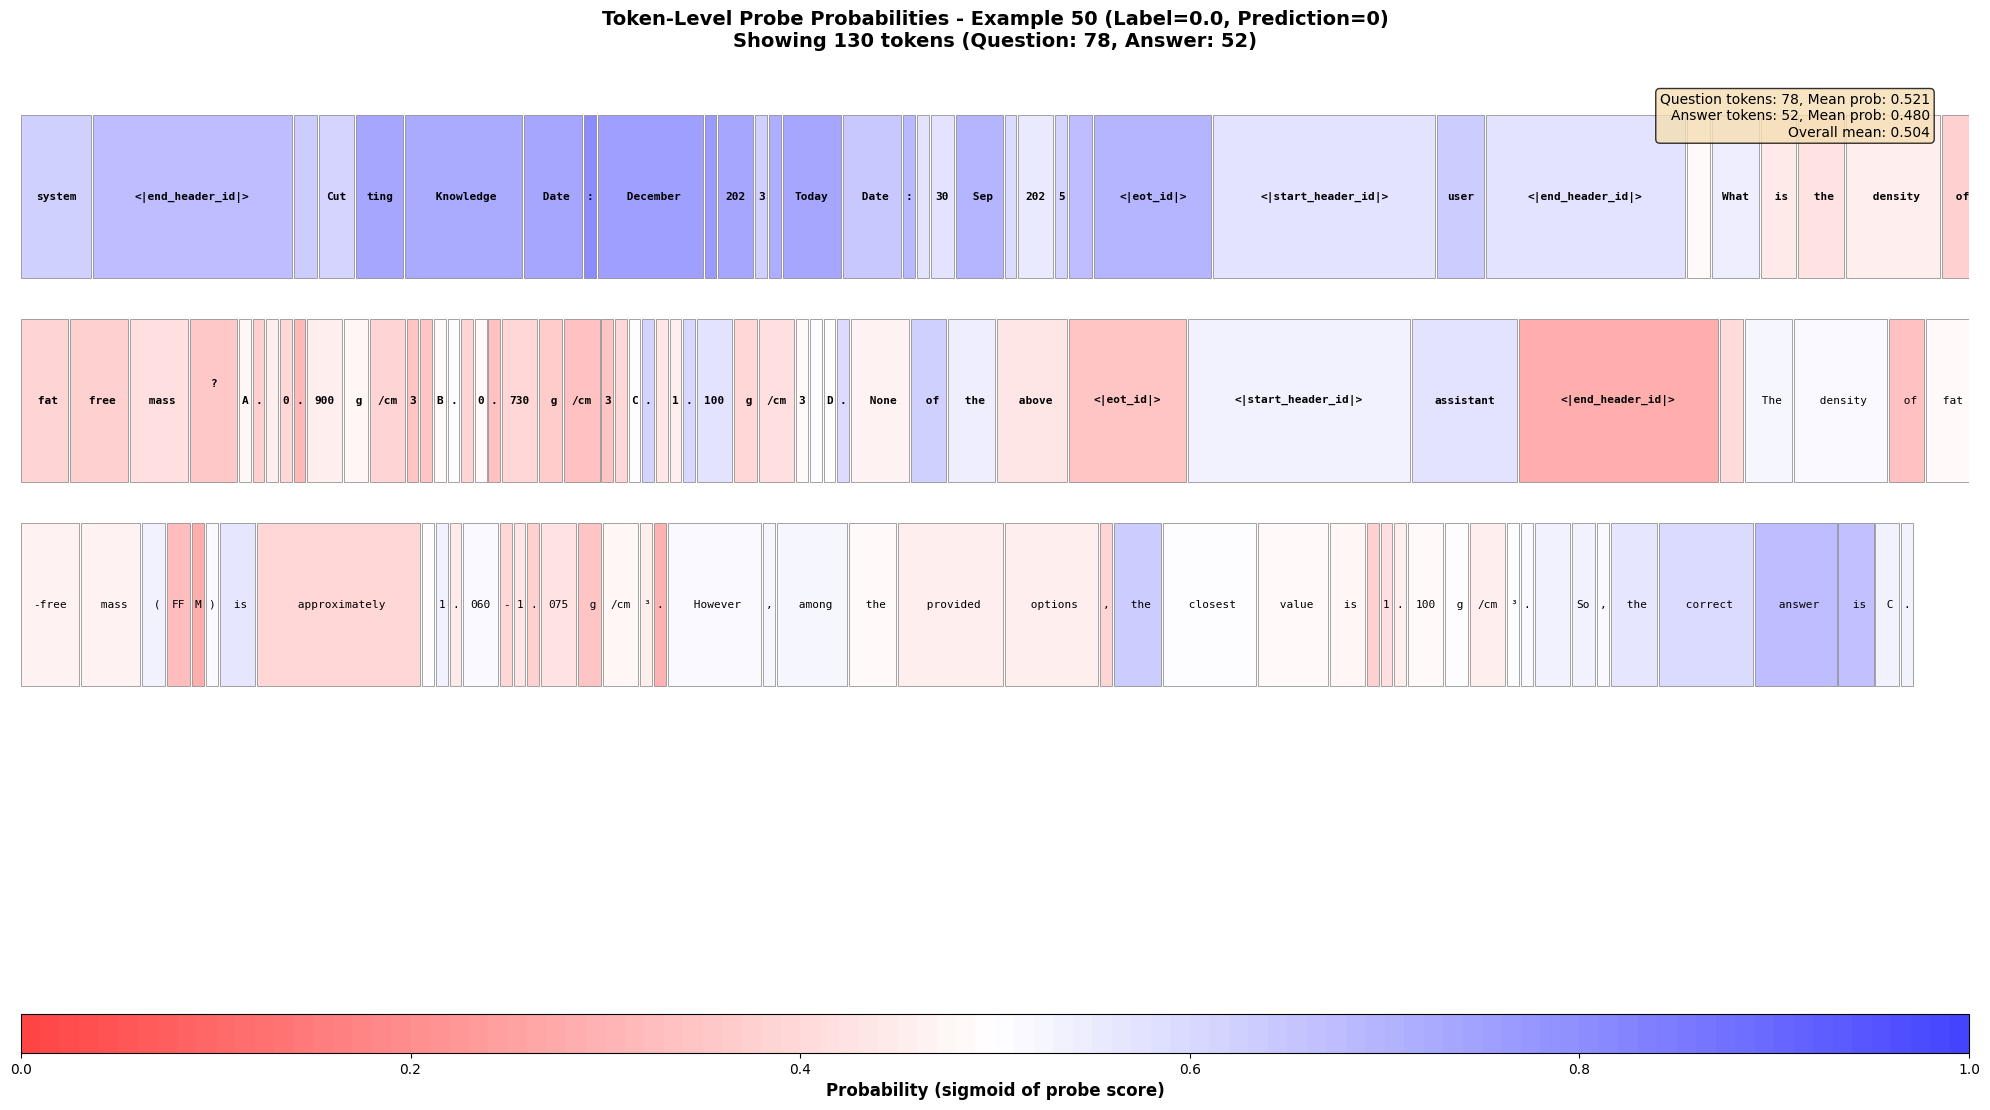





####################################################################################################
LABEL=0 EXAMPLE 4/10
####################################################################################################

EXAMPLE 67 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.055 | Probability: 0.486

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

The semicircular canals of the inner ear are important for helping a person to maintain

A. tone quality
B. melatonin
C. balance
D. olfaction<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is C. balance.

The semicircular canals are a part of the vestibular system in the inner ear, which is responsible for maintaining balance and equilibrium. They contain fluid-filled canals lined with sensory hair cells that detect movem

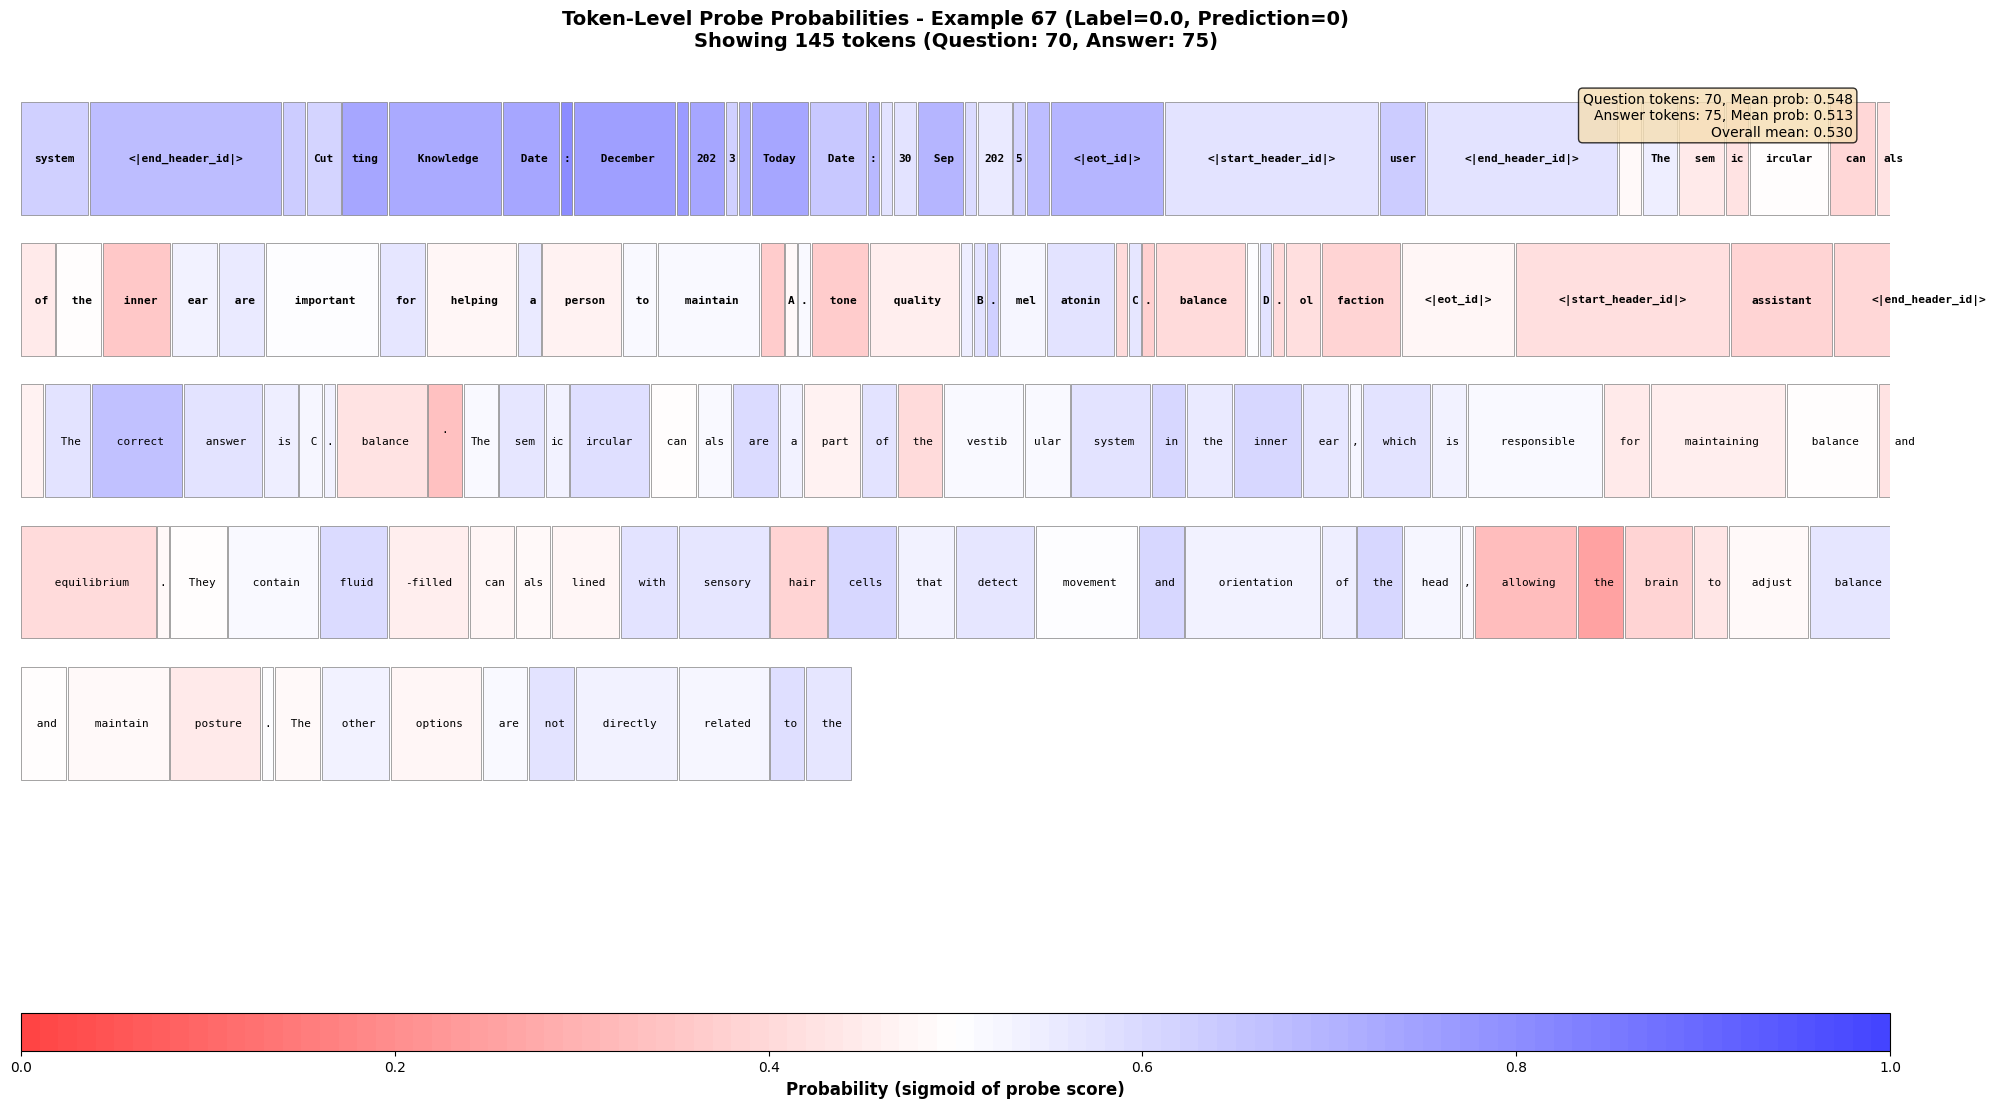





####################################################################################################
LABEL=0 EXAMPLE 5/10
####################################################################################################

EXAMPLE 178 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.123 | Probability: 0.469

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Why are there no impact craters on the surface of Io?

A. Io did have impact craters but they have all been buried in lava flows.
B. It is too small to have been hit during the Late Heavy Bombardment
C. Jupiter's strong gravity attracted the planetesimals more strongly than Io and thus none landed on its surface.
D. Any craters that existed have been eroded through the strong winds on Io's surface.<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE AN

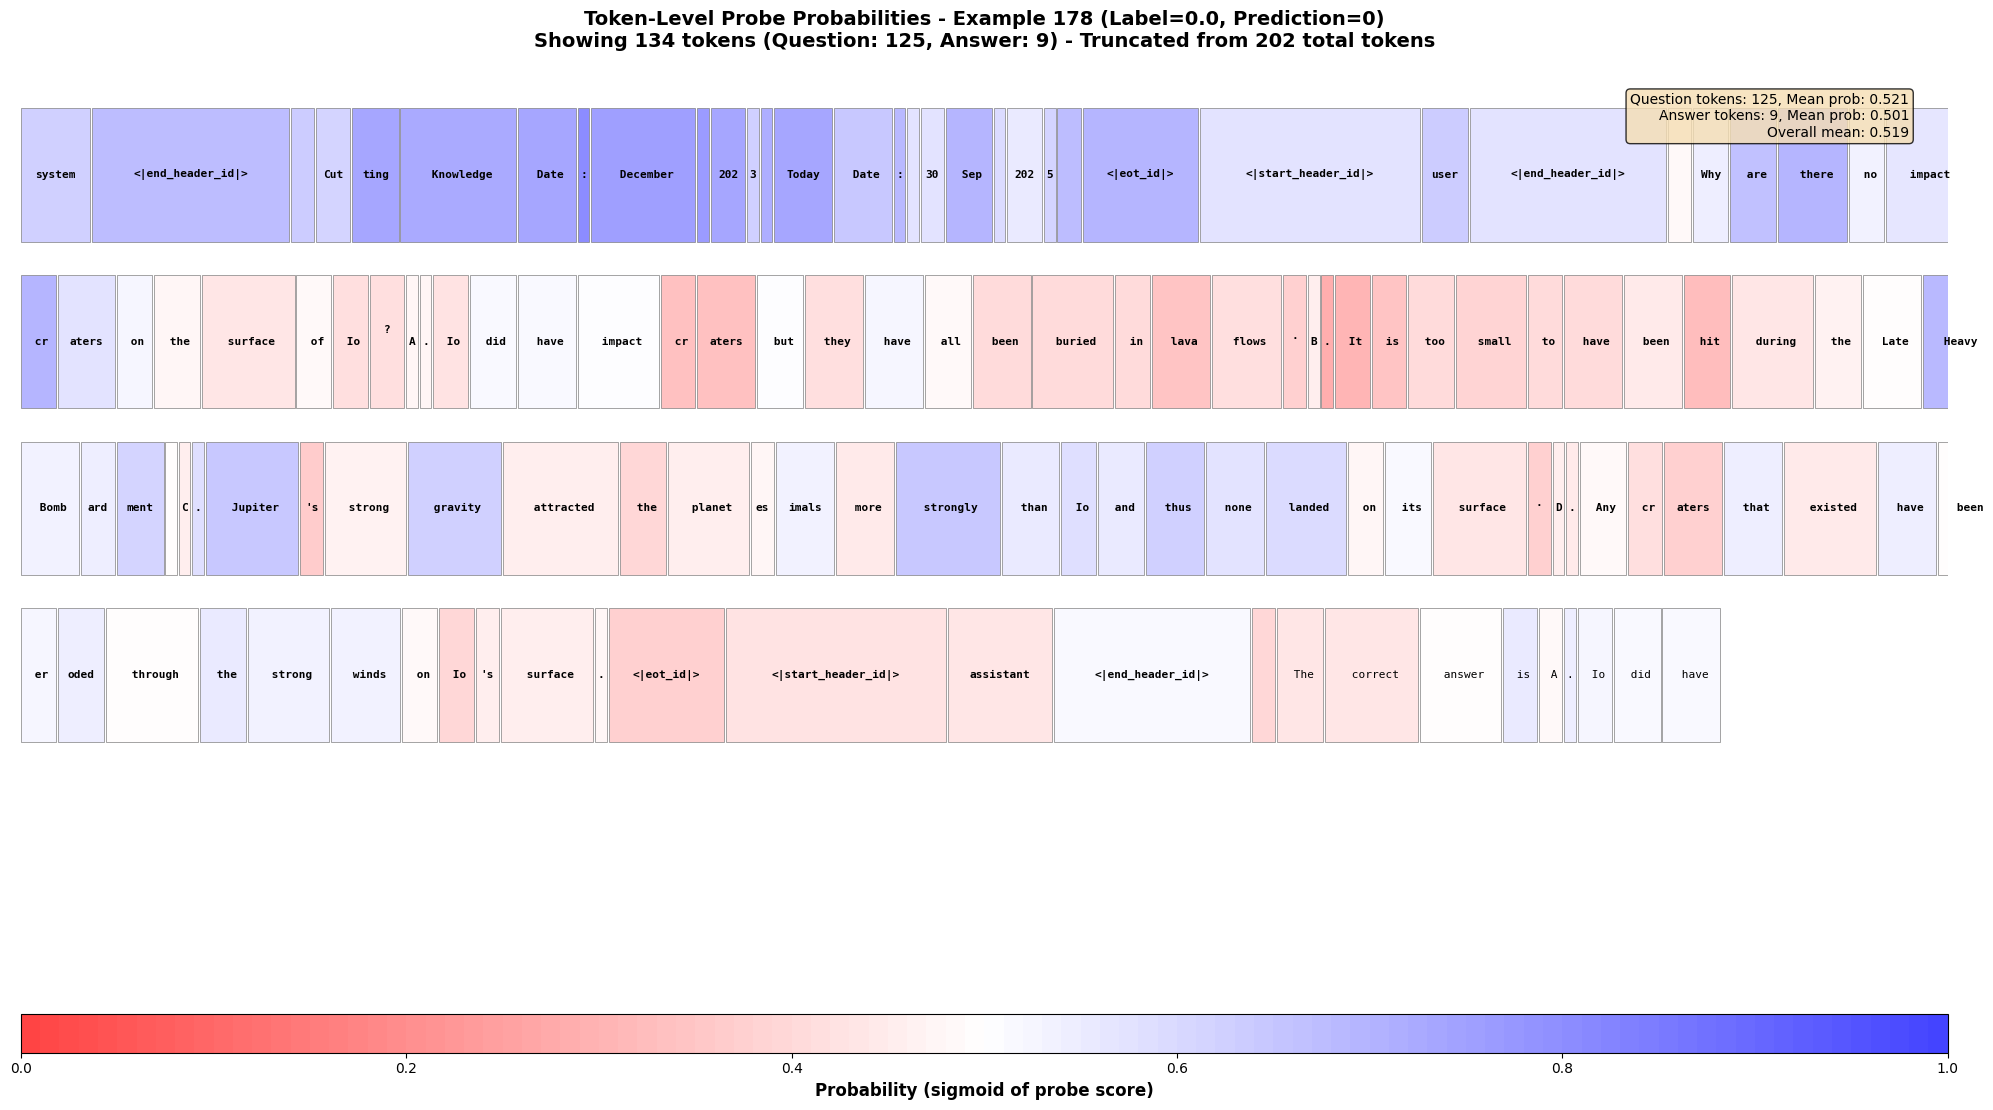





####################################################################################################
LABEL=0 EXAMPLE 6/10
####################################################################################################

EXAMPLE 185 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.003 | Probability: 0.499

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

The expression to signify any assumption which conceals of affects to conceal the fact that a rule of law has undergone alteration, its letter being unchanged, its operation being modified is :

A. Legal fiction
B. Equity
C. Custom
D. Legislation<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is A. Legal fiction.

A legal fiction is a concept in law that refers to a hypothetical or artificial situation created to facilit

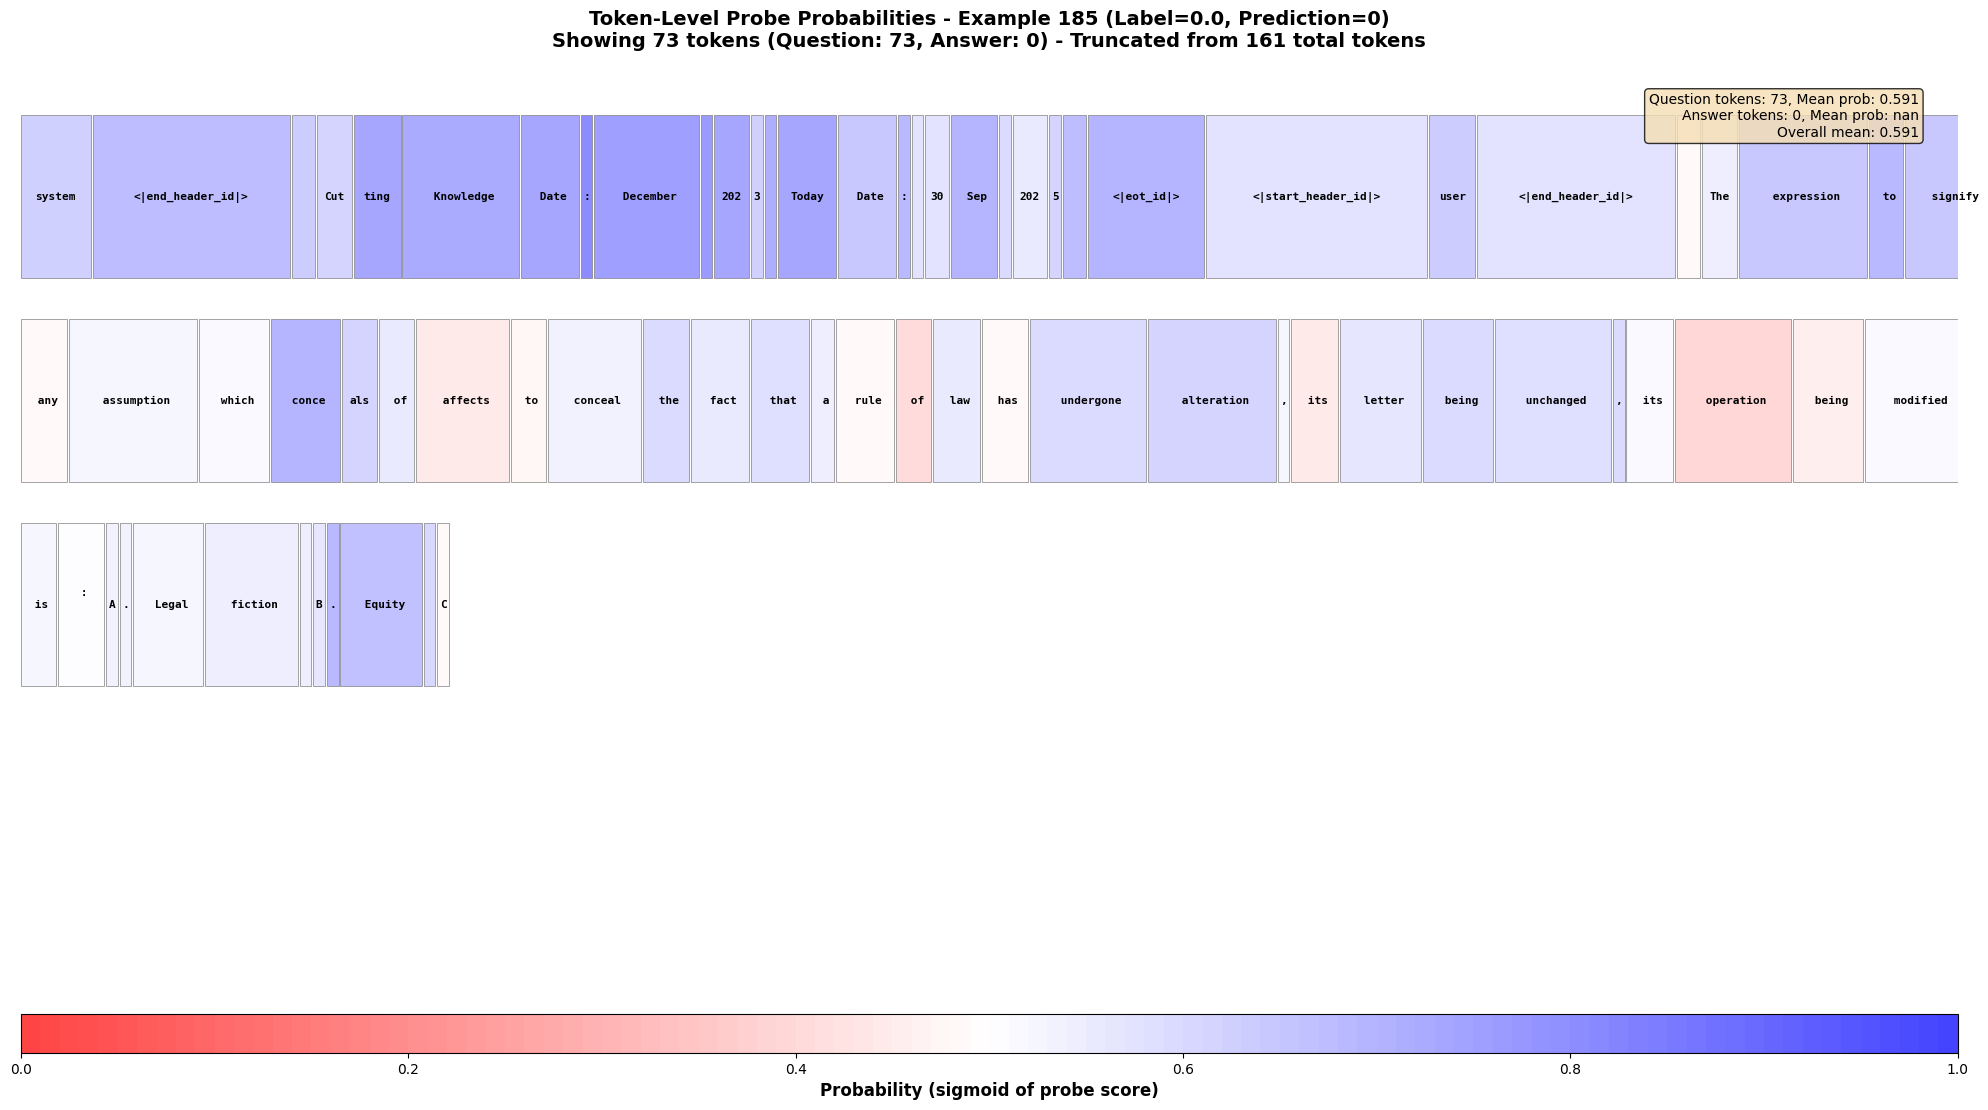





####################################################################################################
LABEL=0 EXAMPLE 7/10
####################################################################################################

EXAMPLE 201 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.043 | Probability: 0.489

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Robert and Tanya are married and live with their three children. Their family unit is called

A. a family of orientation
B. a nuclear family
C. an extended family
D. a communal family<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is B. a nuclear family.

A nuclear family is a family consisting of two parents and their dependent children, typically living together in one household. In this case, Robert and Tanya are the 

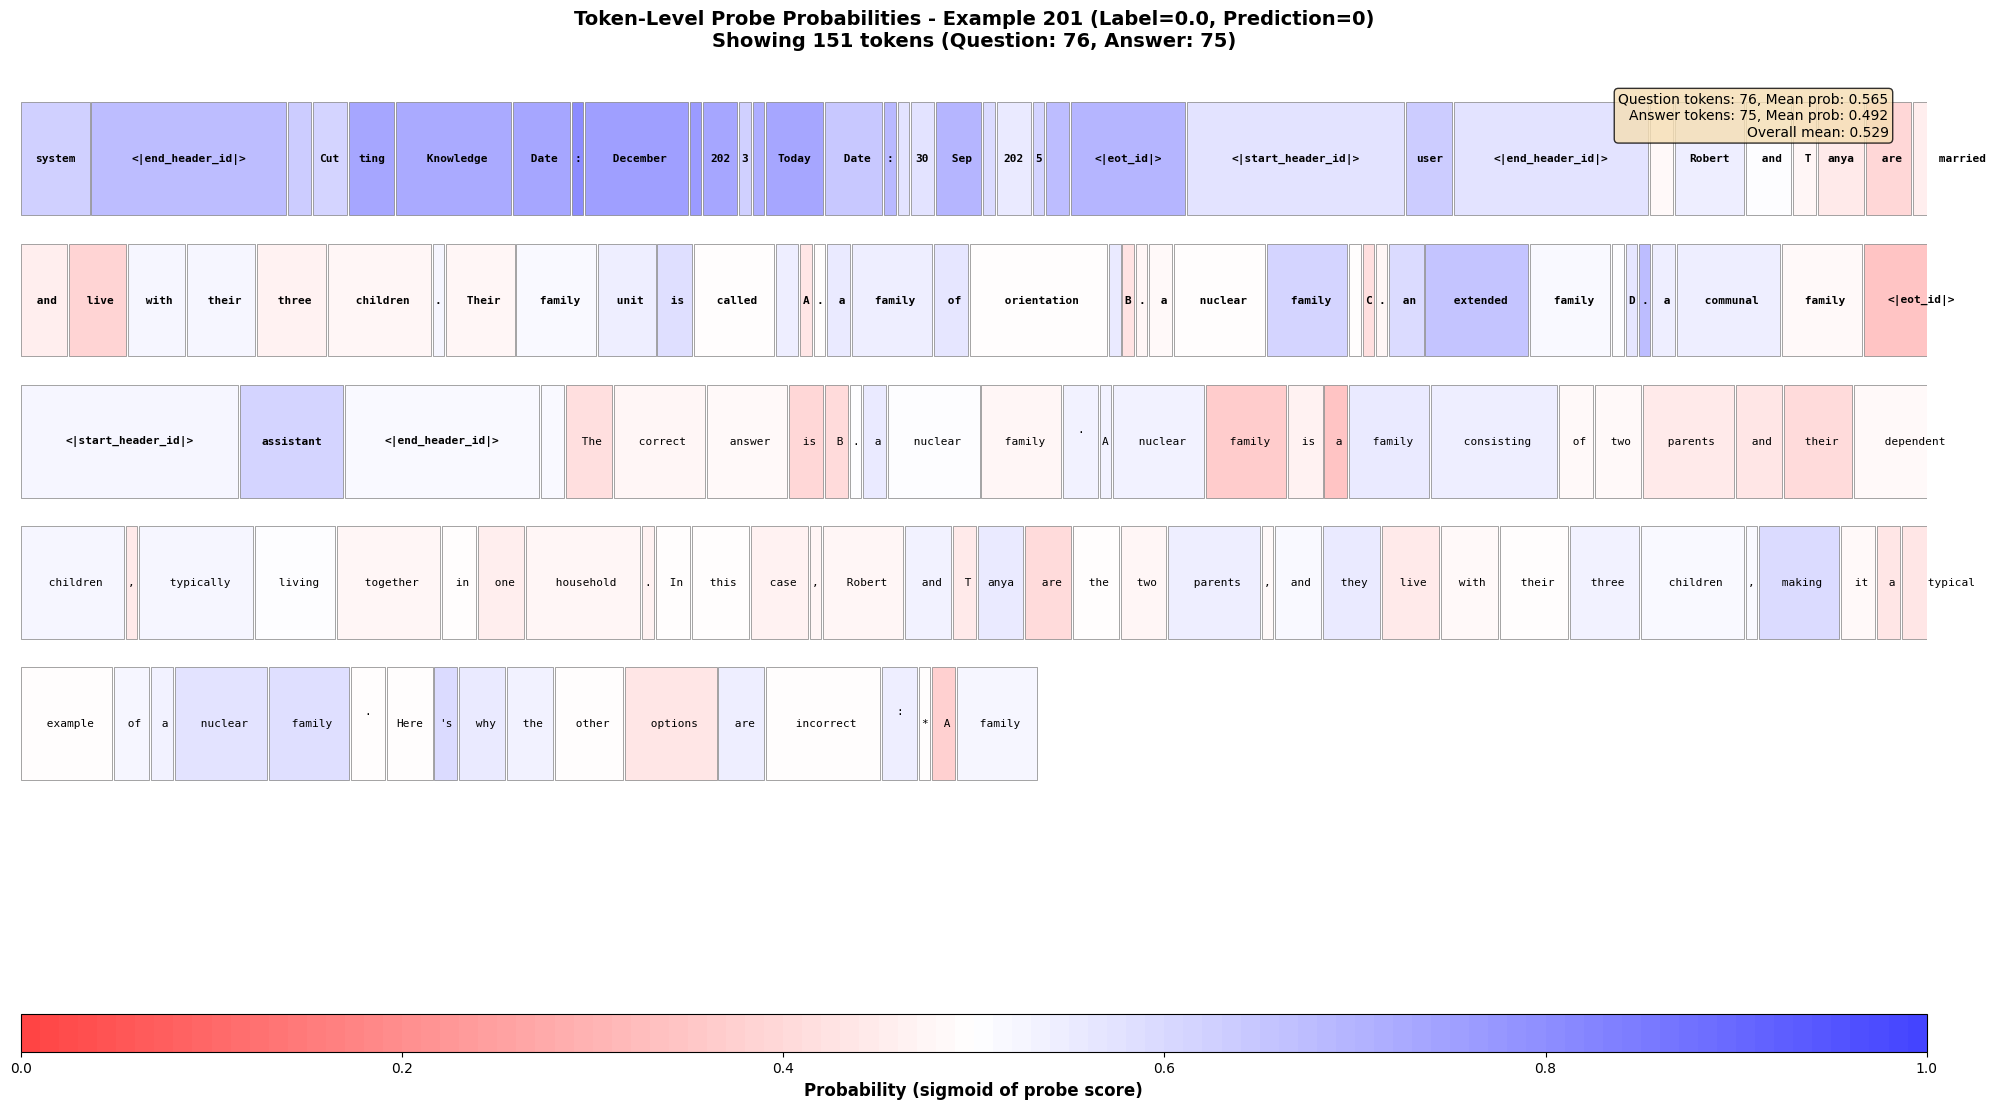





####################################################################################################
LABEL=0 EXAMPLE 8/10
####################################################################################################

EXAMPLE 259 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.087 | Probability: 0.478

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

This question refers to the following information.
Every two months His Majesty sends from Lima 60,000 pesos to pay for the mita of the Indians. Up on the Huanacavelica range there are 3,000 or 4,000 Indians working in the mercury mine, with picks and hammers, breaking up the ore. And when they have filled up their little sacks, the poor fellows, loaded down, climb up those ladders and rigging, so distressing that a man can hardly get up them. That is the way they wo

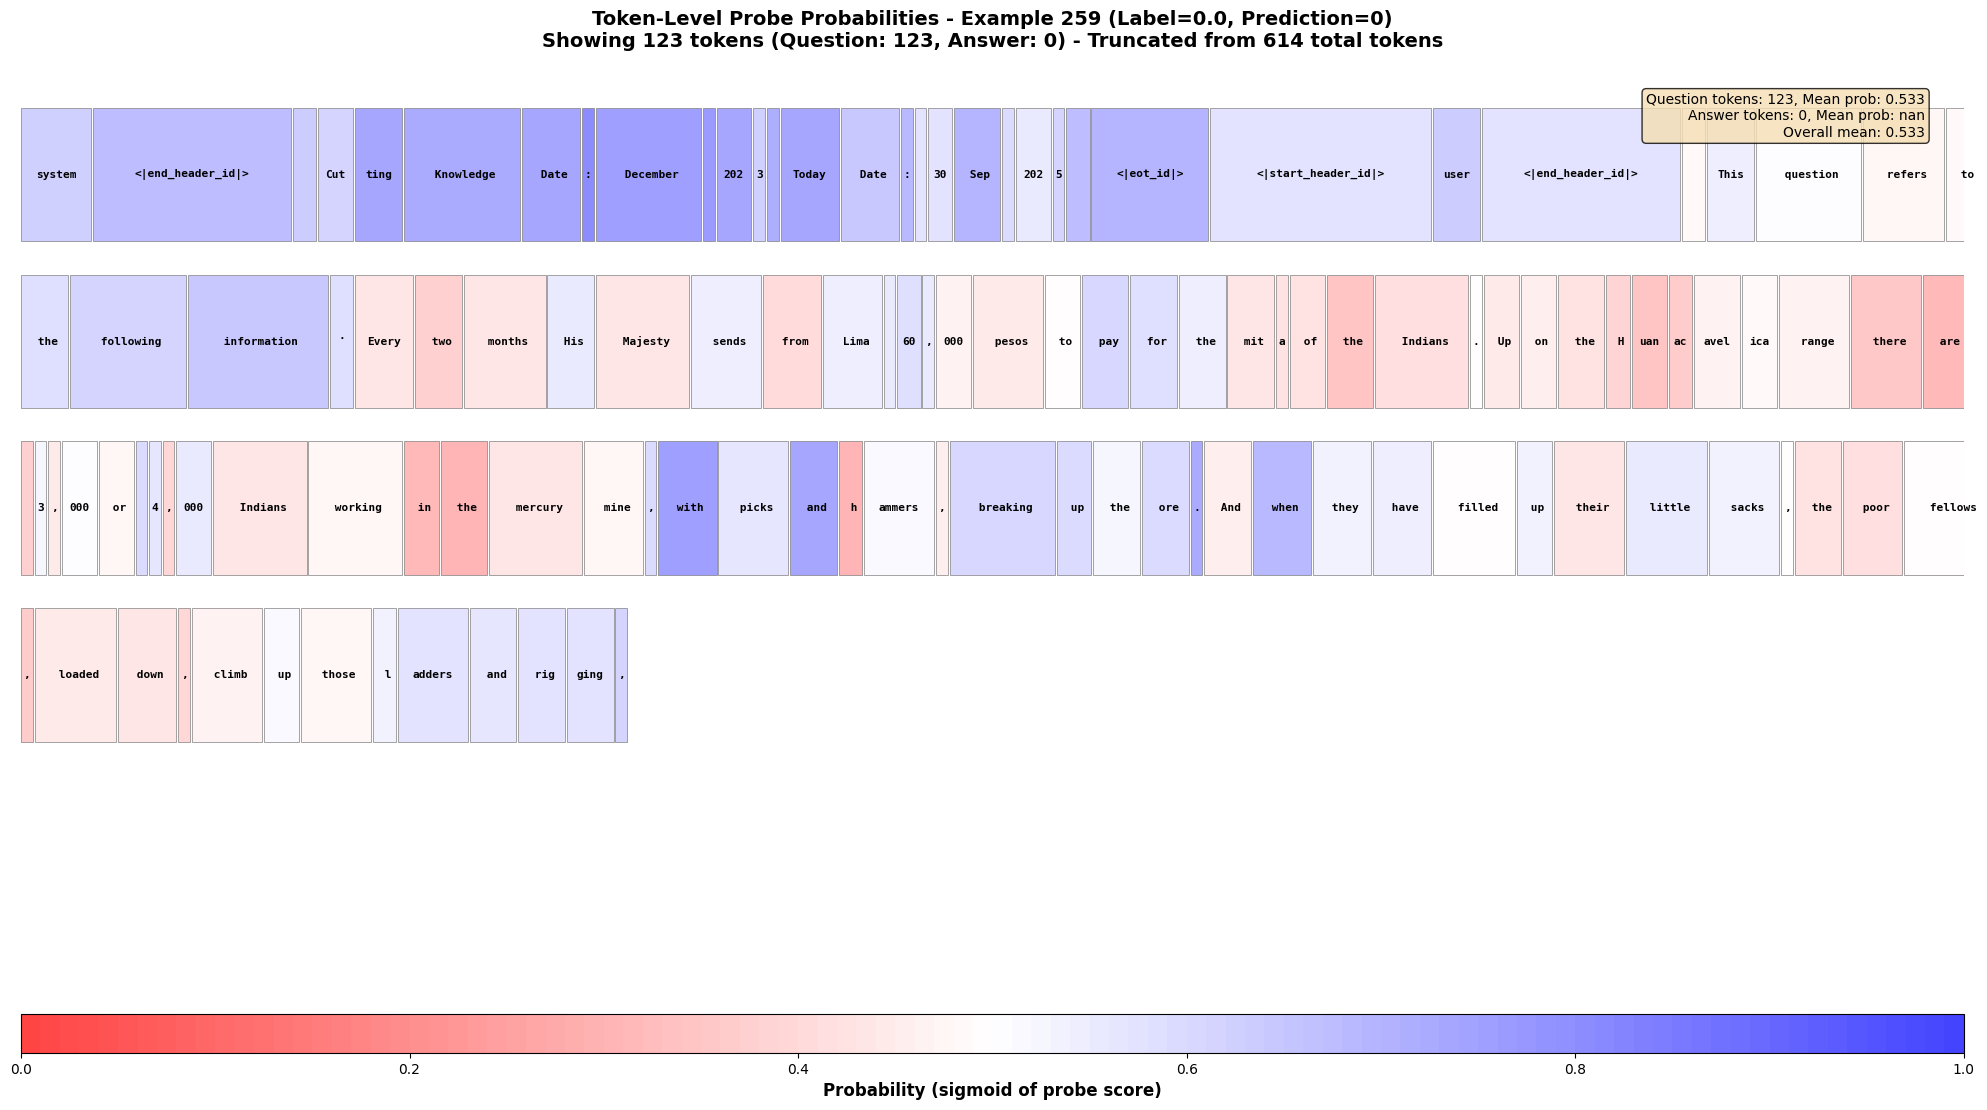





####################################################################################################
LABEL=0 EXAMPLE 9/10
####################################################################################################

EXAMPLE 296 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.117 | Probability: 0.471

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Which of the following is NOT a sign of phlebitis?

A. Swelling.
B. Redness.
C. Exudate.
D. Cool to the touch.<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is D. Cool to the touch.

Phlebitis is inflammation of a vein, and the typical signs and symptoms include:

- Swelling (A) of the affected limb
- Redness (B) of the skin
- Warmth or tenderness to the touch
- Exudate (C) or discharge from the vein

Being cool

⚠️  NO

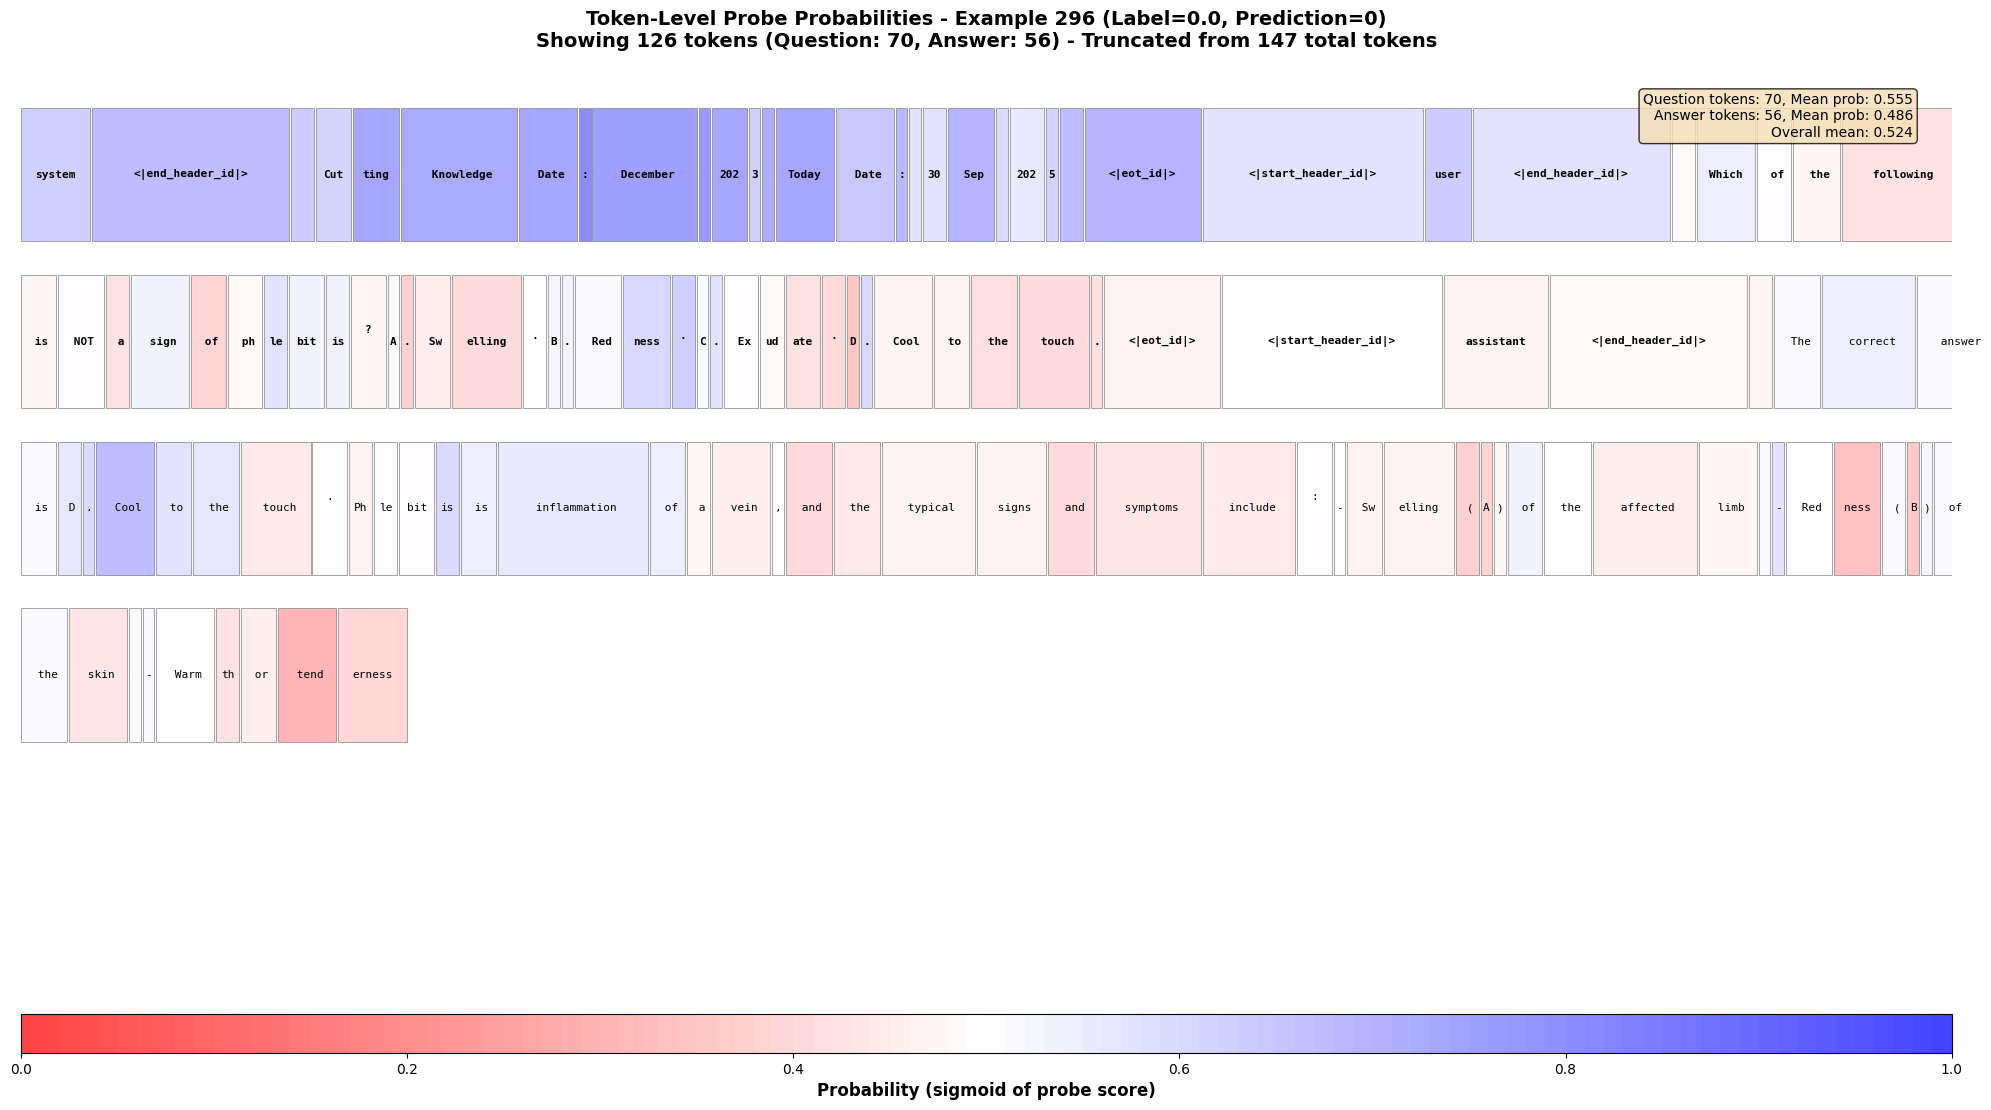





####################################################################################################
LABEL=0 EXAMPLE 10/10
####################################################################################################

EXAMPLE 343 - TRUE LABEL: 0.0 | PROBE PREDICTION: 0 | ✓ CORRECT
Probe score: -0.066 | Probability: 0.484

COMPLETE QUESTION:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Sep 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

According to Malinowski, the Trobriand Islanders organized their society around what concept?

A. Conflict.
B. Love.
C. War.
D. Reciprocity.<|eot_id|><|start_header_id|>assistant<|end_header_id|>



COMPLETE ANSWER:
The correct answer is D. Reciprocity.

In Bronislaw Malinowski's work, he described the Trobriand Islanders' society as being based on reciprocity, rather than kinship or prestige. The Trobriand Islanders, a Melanesian people from Papua New Guinea, organ

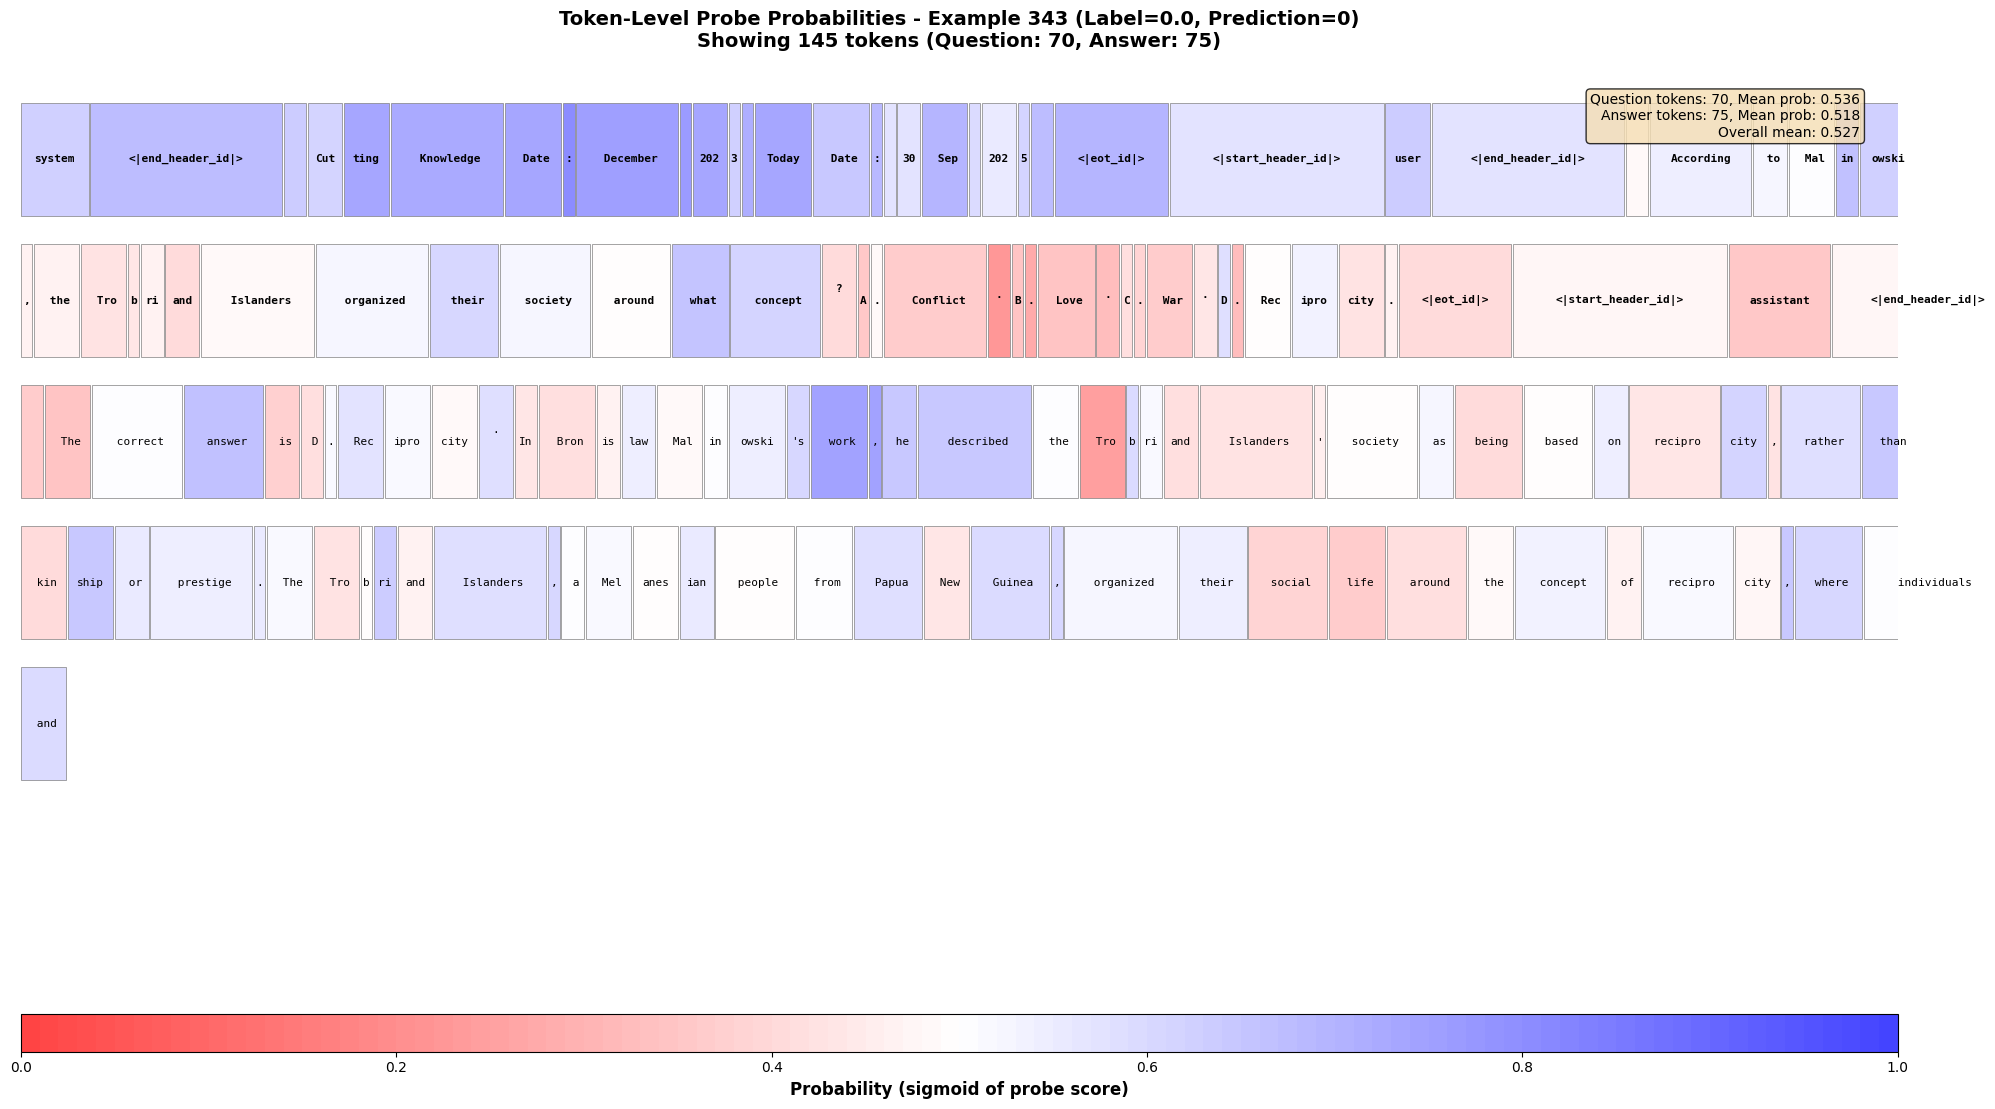




COMPLETED: Visualized 10 label=1 + 10 label=0 = 20 total examples


In [23]:
# Visualize multiple correctly classified examples
# Change num_examples_per_label to show more or fewer examples

num_examples_per_label = 10  # Number of examples to show for each label

# probe_type = "mean"  # Options: "mean", "attention_torch", "mean_torch"
# behaviour = "science"
# datasource = "ultrachat"
# activations_model = "llama_3b"
# generation_method = "on_policy"
# response_model = "llama_3b"
# off_policy_model = "qwen_3b"
# mode = "train"



# Visualize LABEL=1 examples
print("\n" + "="*100)
print(f"VISUALIZING {min(num_examples_per_label, len(correctly_classified_label_1))} CORRECTLY CLASSIFIED LABEL=1 EXAMPLES")
print("="*100)

for i in range(min(num_examples_per_label, len(correctly_classified_label_1))):
    print(f"\n{'#'*100}")
    print(f"LABEL=1 EXAMPLE {i+1}/{min(num_examples_per_label, len(correctly_classified_label_1))}")
    print(f"{'#'*100}")
    visualize_token_heatmap(correctly_classified_label_1[i], model_name = activations_model, dataset_name = datasource, behavior = behaviour, generation_method = generation_method, probe_type = probe_type)
    print("\n\n")

if len(correctly_classified_label_1) == 0:
    print("⚠️  No correctly classified label=1 examples available!")

# Visualize LABEL=0 examples
print("\n" + "="*100)
print(f"VISUALIZING {min(num_examples_per_label, len(correctly_classified_label_0))} CORRECTLY CLASSIFIED LABEL=0 EXAMPLES")
print("="*100)

for i in range(min(num_examples_per_label, len(correctly_classified_label_0))):
    print(f"\n{'#'*100}")
    print(f"LABEL=0 EXAMPLE {i+1}/{min(num_examples_per_label, len(correctly_classified_label_0))}")
    print(f"{'#'*100}")
    visualize_token_heatmap(correctly_classified_label_0[i])
    print("\n\n")

if len(correctly_classified_label_0) == 0:
    print("⚠️  No correctly classified label=0 examples available!")

print("="*100)
print(f"COMPLETED: Visualized {min(num_examples_per_label, len(correctly_classified_label_1))} label=1 + {min(num_examples_per_label, len(correctly_classified_label_0))} label=0 = {min(num_examples_per_label, len(correctly_classified_label_1)) + min(num_examples_per_label, len(correctly_classified_label_0))} total examples")
print("="*100)
